# New York Quarterly Emergency Department Demand Forecasting
**DATA 975 Capstone — Thi Thanh Hien Bui (Emi)**

### SQL-refactored portfolio version
The original project workflow is preserved from EDA through model evaluation and deployment. The main change is that **Oracle SQL now owns data cleaning, aggregation, joins, temporal alignment, and core feature engineering**. Python starts from the SQL-prepared county-quarter panel and continues with EDA, feature selection, forecasting, validation, and artifact export.


## 0 · Setup and imports

Run this notebook locally in **VS Code/Jupyter** using the project `.venv`.

The notebook is intentionally ordered so that **project paths are created first**, before any optional modeling package import. This prevents a failed package import from leaving variables such as `ANALYSIS_TABLE_PATH` undefined.

**Recommended execution:** select the project kernel, then use **Restart Kernel → Run All**.

The notebook may be launched from either:

- `ed_demand_app/`, or
- `ed_demand_app/notebooks/`

The project root is resolved automatically.

**Expected SQL-prepared input before modeling:**

`data/processed/county_quarter_analysis.csv`

That file is exported from Oracle after running and validating:

`sql/01_build_county_quarter_analysis.sql`

The raw SPARCS file is optional and is used only for the original statewide descriptive-context chart:

`data/raw/sparcs_ed_facility_quarter.csv`


In [1]:
from pathlib import Path
import math
import os
import re
import sys
import warnings

# ------------------------------------------------------------
# Resolve the local project root FIRST.
# ------------------------------------------------------------
CURRENT_DIR = Path.cwd().resolve()

candidate_roots = [
    CURRENT_DIR,
    CURRENT_DIR.parent,
    Path(r"C:\Users\emily\DATA_SCIENCE\PROJECT\ed_demand_app"),
]

PROJECT_DIR = None

for candidate in candidate_roots:
    if (
        (candidate / "sql").exists()
        and (candidate / "notebooks").exists()
    ):
        PROJECT_DIR = candidate
        break

if PROJECT_DIR is None:
    raise FileNotFoundError(
        "Could not locate the ed_demand_app project root. "
        "Open C:\\Users\\emily\\DATA_SCIENCE\\PROJECT\\ed_demand_app "
        "as the VS Code folder, then restart the kernel and Run All."
    )

RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
MODEL_DIR = PROJECT_DIR / "model"
REPORT_DIR = PROJECT_DIR / "reports"
IMAGE_DIR = REPORT_DIR / "images"

for folder in [
    RAW_DIR,
    PROCESSED_DIR,
    MODEL_DIR,
    REPORT_DIR,
    IMAGE_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

ANALYSIS_TABLE_PATH = (
    PROCESSED_DIR / "county_quarter_analysis.csv"
)

FACILITY_RAW_PATH = (
    RAW_DIR / "sparcs_ed_facility_quarter.csv"
)

print("Project folder:", PROJECT_DIR)
print("Analysis table:", ANALYSIS_TABLE_PATH)
print("Analysis table exists:", ANALYSIS_TABLE_PATH.exists())
print("Raw SPARCS exists:", FACILITY_RAW_PATH.exists())


Project folder: C:\Users\emily\DATA_SCIENCE\PROJECT\ed_demand_app
Analysis table: C:\Users\emily\DATA_SCIENCE\PROJECT\ed_demand_app\data\processed\county_quarter_analysis.csv
Analysis table exists: True
Raw SPARCS exists: True


### 0.1 · Modeling environment and imports

The local project paths above are initialized before the modeling stack is loaded.

The code below preserves the original notebook behavior for XGBoost and SHAP: if either package is missing from the selected `.venv` kernel, the notebook installs it into that environment and then continues.


In [2]:
import subprocess
import sklearn

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import xgboost as xgb
    from xgboost import XGBRegressor
except ImportError:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "xgboost"]
    )
    import xgboost as xgb
    from xgboost import XGBRegressor

try:
    import shap
except ImportError:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "shap"]
    )
    import shap

from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

print("Python:", sys.version.split()[0])
print("scikit-learn:", sklearn.__version__)
print("XGBoost:", xgb.__version__)
print("SHAP:", shap.__version__)


Python: 3.12.5
scikit-learn: 1.6.1
XGBoost: 3.3.0
SHAP: 0.52.0


## 1 · Phase 1 — Configuration

The modeling definitions from the original project remain unchanged. The target is quarterly total ED encounters at the facility-county level, and the final holdout is determined from complete county-quarter coverage in the SQL-prepared panel.


In [3]:
TARGET = "total_ed_encounters"
MIN_TRAIN_QUARTERS = 8

print("Forecasting target:", TARGET)


Forecasting target: total_ed_encounters


# Phase 2 — SQL-prepared analytical panel

## 2 · Shared helper functions

The visualization and formatting helpers below are preserved from the original notebook. Data-download helpers are no longer needed here because ingestion/preparation is now upstream of the modeling notebook.


In [4]:
def clean_column_names(df):
    out = df.copy()
    out.columns = (
        out.columns.astype(str)
        .str.lower()
        .str.strip()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
        .str.replace("/", "_", regex=False)
        .str.replace("(", "", regex=False)
        .str.replace(")", "", regex=False)
    )
    return out


def to_num(series):
    return pd.to_numeric(
        series.astype(str).str.replace(",", "", regex=False),
        errors="coerce",
    )


def name_key(value):
    text = str(value).lower().split(",")[0]
    text = text.replace("county", "").replace(".", "").replace("'", "")
    return re.sub(r"\s+", " ", text).strip()



def format_count(value):
    """Format encounter counts and other whole-number chart labels."""
    if pd.isna(value):
        return ""
    return f"{float(value):,.0f}"


def format_decimal(value, digits=2):
    """Format continuous chart values without unnecessary scientific notation."""
    if pd.isna(value):
        return ""
    return f"{float(value):,.{digits}f}"


def add_line_value_labels(
    ax,
    x_values,
    y_values,
    formatter=format_count,
    fontsize=7,
    offset_points=7,
):
    """Place a readable value above every point in a line chart."""
    for x_value, y_value in zip(x_values, y_values):
        if pd.isna(y_value):
            continue
        ax.annotate(
            formatter(y_value),
            xy=(x_value, y_value),
            xytext=(0, offset_points),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=fontsize,
        )


def add_bar_value_labels(
    ax,
    bars,
    formatter=format_count,
    horizontal=False,
    fontsize=8,
):
    """Label every bar using its displayed value."""
    values = [
        bar.get_width() if horizontal else bar.get_height()
        for bar in bars
    ]
    labels = [formatter(value) for value in values]
    ax.bar_label(
        bars,
        labels=labels,
        padding=3,
        fontsize=fontsize,
        label_type="edge",
    )


def add_histogram_count_labels(ax, patches, fontsize=7):
    """Show the frequency above each nonempty histogram bin."""
    for patch in patches:
        count = patch.get_height()
        if count <= 0:
            continue
        ax.annotate(
            f"{int(round(count)):,}",
            xy=(
                patch.get_x() + patch.get_width() / 2,
                count,
            ),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=fontsize,
            rotation=90,
        )


def add_selected_scatter_labels(
    ax,
    frame,
    x_column,
    y_column,
    label_column=None,
    score_column=None,
    n_labels=10,
    x_formatter=lambda value: format_decimal(value, 1),
    y_formatter=lambda value: format_decimal(value, 1),
    note="Labels show the 10 most informative observations.",
):
    """
    Label a readable subset of a dense scatterplot.

    By default, the largest y-values are labeled. When score_column is given,
    observations with the largest absolute score are labeled instead.
    """
    required = [x_column, y_column]
    if label_column is not None:
        required.append(label_column)
    if score_column is not None and score_column not in required:
        required.append(score_column)

    valid = frame[required].dropna(subset=[x_column, y_column]).copy()
    if valid.empty:
        return

    if score_column is None:
        valid["_label_score"] = valid[y_column]
    else:
        valid["_label_score"] = valid[score_column].abs()

    selected = valid.nlargest(min(n_labels, len(valid)), "_label_score")

    offsets = [
        (5, 5),
        (5, -12),
        (-5, 5),
        (-5, -12),
    ]

    for position, (_, row) in enumerate(selected.iterrows()):
        prefix = ""
        if label_column is not None and pd.notna(row[label_column]):
            prefix = f"{row[label_column]}\n"

        label = (
            f"{prefix}"
            f"({x_formatter(row[x_column])}, "
            f"{y_formatter(row[y_column])})"
        )
        offset_x, offset_y = offsets[position % len(offsets)]
        ax.annotate(
            label,
            xy=(row[x_column], row[y_column]),
            xytext=(offset_x, offset_y),
            textcoords="offset points",
            ha="left" if offset_x >= 0 else "right",
            va="bottom" if offset_y >= 0 else "top",
            fontsize=7,
            alpha=0.85,
        )

    ax.text(
        0.01,
        0.99,
        note,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8,
        alpha=0.7,
    )


## 3 · Load the Oracle SQL output

The former Python sections for raw cleaning, facility-to-county aggregation, ACS preparation, weather aggregation, joining, and lag engineering have been moved to:

`sql/01_build_county_quarter_analysis.sql`

This notebook intentionally does **not** repeat those transformations. It validates the SQL output, preserves the original holdout logic, and then continues with the original EDA/modeling workflow.


In [5]:
# ============================================================
# 3 · Load and validate the Oracle SQL output
# ============================================================
#
# IMPORTANT:
# All substantive data preparation is already completed in Oracle SQL:
#   - raw-value cleaning
#   - facility → county-quarter aggregation
#   - ED / ACS / weather / geography joins
#   - temporal alignment
#   - lag features
#   - regional/time features
#
# Python does NOT rebuild those transformations here.
#
# This cell only:
#   1. loads the SQL-exported analytical table,
#   2. normalizes CSV/header formatting,
#   3. enforces a few key datatypes,
#   4. validates the expected SQL schema,
#   5. optionally loads raw SPARCS for one descriptive EDA chart.
# ============================================================


# ------------------------------------------------------------
# 1. Confirm notebook setup has already run
# ------------------------------------------------------------

required_setup_names = [
    "ANALYSIS_TABLE_PATH",
    "FACILITY_RAW_PATH",
    "TARGET",
]

missing_setup_names = [
    name
    for name in required_setup_names
    if name not in globals()
]

if missing_setup_names:
    raise RuntimeError(
        "Notebook setup is incomplete. Missing: "
        + ", ".join(missing_setup_names)
        + ". Restart the kernel and Run All from the top."
    )


# ------------------------------------------------------------
# 2. Confirm the SQL-exported analytical table exists
# ------------------------------------------------------------

if not ANALYSIS_TABLE_PATH.exists():
    raise FileNotFoundError(
        "SQL-prepared panel not found.\n\n"
        "Run and validate:\n"
        "sql/01_build_county_quarter_analysis.sql\n\n"
        "Then export FINAL_COUNTY_QUARTER_ANALYSIS to:\n"
        f"{ANALYSIS_TABLE_PATH}"
    )


# ------------------------------------------------------------
# 3. Load the SQL-prepared county-quarter table
# ------------------------------------------------------------

# Standard CSV export should be comma-delimited.
quarterly_panel = pd.read_csv(
    ANALYSIS_TABLE_PATH
)

# If SQL Developer exported the file with another delimiter,
# pandas may read the whole table as one column.
# Only in that case, retry with delimiter auto-detection.
if quarterly_panel.shape[1] == 1:
    print(
        "Only one column was detected. "
        "Retrying CSV import with automatic delimiter detection..."
    )

    quarterly_panel = pd.read_csv(
        ANALYSIS_TABLE_PATH,
        sep=None,
        engine="python",
    )


# ------------------------------------------------------------
# 4. Normalize exported column names
# ------------------------------------------------------------
#
# Oracle / SQL Developer commonly exports identifiers in uppercase.
# This is file-interface normalization only; it is NOT data cleaning.
#
# Examples:
#   FIPS            → fips
#   YEAR            → year
#   QUARTER_Q2      → quarter_q2
# ------------------------------------------------------------

quarterly_panel.columns = (
    quarterly_panel.columns
    .astype(str)
    .str.replace("\ufeff", "", regex=False)   # remove possible BOM
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)


print("SQL export loaded successfully.")
print(f"Rows: {len(quarterly_panel):,}")
print(f"Columns: {len(quarterly_panel.columns)}")

print("\nDetected columns:")
print(quarterly_panel.columns.tolist())


# ------------------------------------------------------------
# 5. Validate essential key columns BEFORE accessing them
# ------------------------------------------------------------

key_columns = {
    "fips",
    "year",
    "quarter",
    "quarter_num",
    "period_index",
}

missing_key_columns = sorted(
    key_columns - set(quarterly_panel.columns)
)

if missing_key_columns:
    raise KeyError(
        "The SQL export is missing required key columns:\n"
        + "\n".join(
            f"- {column}"
            for column in missing_key_columns
        )
        + "\n\nActual columns detected:\n"
        + ", ".join(quarterly_panel.columns)
    )


# ------------------------------------------------------------
# 6. Normalize key datatypes
# ------------------------------------------------------------
#
# These are import/datatype corrections only.
# Business transformations remain in SQL.
# ------------------------------------------------------------

quarterly_panel["fips"] = (
    quarterly_panel["fips"]
    .astype(str)
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(5)
)

quarterly_panel["year"] = pd.to_numeric(
    quarterly_panel["year"],
    errors="raise",
).astype(int)

quarterly_panel["quarter_num"] = pd.to_numeric(
    quarterly_panel["quarter_num"],
    errors="raise",
).astype(int)

quarterly_panel["period_index"] = pd.to_numeric(
    quarterly_panel["period_index"],
    errors="raise",
).astype(int)

quarterly_panel["quarter"] = (
    quarterly_panel["quarter"]
    .astype(str)
    .str.strip()
    .str.upper()
)


# ------------------------------------------------------------
# 7. Validate the complete analytical schema
# ------------------------------------------------------------

required_columns = {
    # Grain / identifiers
    "fips",
    "year",
    "quarter",
    "quarter_num",
    "period_index",
    "county_name",
    "lat",
    "lon",

    # Target
    TARGET,

    # Historical target features
    "target_lag1",
    "target_lag2",
    "target_lag3",
    "target_lag4",
    "target_roll4",
    "facility_count_lag1",

    # ACS features
    "acs_lag2_population",
    "acs_lag2_population_100k",
    "acs_lag2_median_income",
    "acs_lag2_poverty_rate",
    "acs_lag2_pct_under5",
    "acs_lag2_pct_65plus",
    "acs_source_year",

    # Weather features
    "weather_lag4_days_observed",
    "weather_lag4_tavg_mean",
    "weather_lag4_precip_total",
    "weather_lag4_snowfall_total",
    "weather_lag4_hot_days",
    "weather_lag4_freeze_days",
    "weather_lag4_wet_days",
    "weather_source_year",

    # Time features
    "is_covid",
    "post_covid",
    "quarter_q2",
    "quarter_q3",
    "quarter_q4",

    # Geography / regional features
    "is_nyc",
    "is_downstate_non_nyc",
    "region",

    # Descriptive utilization metric
    "facility_ed_encounters_per_100k_proxy",
}


missing_columns = sorted(
    required_columns
    - set(quarterly_panel.columns)
)

if missing_columns:
    raise KeyError(
        "SQL export is missing columns required by the modeling notebook:\n"
        + "\n".join(
            f"- {column}"
            for column in missing_columns
        )
    )


print(
    f"\nSchema check passed: "
    f"{len(required_columns)} required columns verified."
)


# ------------------------------------------------------------
# 8. Basic grain validation
# ------------------------------------------------------------

duplicate_count = int(
    quarterly_panel.duplicated(
        subset=[
            "fips",
            "year",
            "quarter",
        ]
    ).sum()
)

if duplicate_count > 0:
    raise ValueError(
        "The SQL export contains "
        f"{duplicate_count:,} duplicate county-quarter rows."
    )


print("County-quarter grain check passed.")


# ------------------------------------------------------------
# 9. Load raw SPARCS only for original statewide-context EDA
# ------------------------------------------------------------
#
# This file is optional.
#
# It is NOT used for:
#   - cleaning,
#   - aggregation,
#   - joins,
#   - feature engineering,
#   - model training preparation.
#
# It is retained only to reproduce the original statewide
# descriptive EDA chart when statewide summary rows are available.
# ------------------------------------------------------------

facility_raw = None

if FACILITY_RAW_PATH.exists():

    facility_raw = pd.read_csv(
        FACILITY_RAW_PATH,
        dtype=str,
    )

    facility_raw.columns = (
        facility_raw.columns
        .astype(str)
        .str.replace("\ufeff", "", regex=False)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
        .str.replace("/", "_", regex=False)
        .str.replace("(", "", regex=False)
        .str.replace(")", "", regex=False)
    )

    print(
        "\nLoaded raw SPARCS snapshot only for "
        "statewide descriptive context."
    )

else:

    print(
        "\nRaw SPARCS snapshot not found. "
        "The statewide EDA section will use summed county totals."
    )


# ------------------------------------------------------------
# 10. Dataset metadata
# ------------------------------------------------------------

FACILITY_START_YEAR = int(
    quarterly_panel["year"].min()
)

FACILITY_END_YEAR = int(
    quarterly_panel["year"].max()
)

source_for_date = (
    FACILITY_RAW_PATH
    if FACILITY_RAW_PATH.exists()
    else ANALYSIS_TABLE_PATH
)

DATA_AS_OF_DATE = (
    pd.Timestamp.fromtimestamp(
        source_for_date.stat().st_mtime
    )
    .date()
    .isoformat()
)


# ------------------------------------------------------------
# 11. Loading summary
# ------------------------------------------------------------

print("\n--- SQL analytical panel summary ---")

print(
    "Rows:",
    f"{len(quarterly_panel):,}",
)

print(
    "Counties:",
    quarterly_panel["fips"].nunique(),
)

print(
    "Target years:",
    FACILITY_START_YEAR,
    "to",
    FACILITY_END_YEAR,
)

print(
    "Duplicate county-quarter rows:",
    duplicate_count,
)

print(
    "Data snapshot / prepared date:",
    DATA_AS_OF_DATE,
)

print("\nPreview:")

display(
    quarterly_panel.head()
)

SQL export loaded successfully.
Rows: 1,536
Columns: 47

Detected columns:
['fips', 'year', 'quarter', 'quarter_num', 'period_index', 'total_ed_encounters', 'treat_and_release_ed', 'ed_encounters_requiring', 'ed_encounters_admitted_as', 'facility_count', 'facility_row_count', 'facilities_with_ed_data', 'facilities_missing_ed_data', 'component_gap', 'county_name', 'lat', 'lon', 'target_lag1', 'target_lag2', 'target_lag3', 'target_lag4', 'target_roll4', 'facility_count_lag1', 'acs_lag2_population', 'acs_lag2_median_income', 'acs_lag2_poverty_rate', 'acs_lag2_pct_under5', 'acs_lag2_pct_65plus', 'acs_source_year', 'acs_lag2_population_100k', 'weather_lag4_days_observed', 'weather_lag4_tavg_mean', 'weather_lag4_precip_total', 'weather_lag4_snowfall_total', 'weather_lag4_hot_days', 'weather_lag4_freeze_days', 'weather_lag4_wet_days', 'weather_source_year', 'is_covid', 'post_covid', 'quarter_q2', 'quarter_q3', 'quarter_q4', 'is_nyc', 'is_downstate_non_nyc', 'region', 'facility_ed_encounters_p

,fips,year,quarter,quarter_num,period_index,total_ed_encounters,treat_and_release_ed,ed_encounters_requiring,ed_encounters_admitted_as,facility_count,facility_row_count,facilities_with_ed_data,facilities_missing_ed_data,component_gap,county_name,lat,lon,target_lag1,target_lag2,target_lag3,target_lag4,target_roll4,facility_count_lag1,acs_lag2_population,acs_lag2_median_income,acs_lag2_poverty_rate,acs_lag2_pct_under5,acs_lag2_pct_65plus,acs_source_year,acs_lag2_population_100k,weather_lag4_days_observed,weather_lag4_tavg_mean,weather_lag4_precip_total,weather_lag4_snowfall_total,weather_lag4_hot_days,weather_lag4_freeze_days,weather_lag4_wet_days,weather_source_year,is_covid,post_covid,quarter_q2,quarter_q3,quarter_q4,is_nyc,is_downstate_non_nyc,region,facility_ed_encounters_per_100k_proxy
0,36001,2018,Q1,1,8073,42951,32334.0,287.0,10330.0,5,5,3,2,0.0,Albany County,42.588240,-73.974010,NaN,NaN,NaN,NaN,NaN,NaN,307891,60904,12.923933,5.024830,15.213501,2016,3.07891,90,30.038889,10.628,38.911,0,77,47,2017,0,0,0,0,0,0,0,upstate,13950.066744
1,36003,2018,Q1,1,8073,5290,2529.0,14.0,350.0,2,2,2,0,2397.0,Allegany County,42.247853,-78.026153,NaN,NaN,NaN,NaN,NaN,NaN,47700,44085,17.070941,5.140461,16.792453,2016,0.47700,90,30.049444,11.423,27.010,0,71,60,2017,0,0,0,0,0,0,0,upstate,11090.146751
2,36005,2018,Q1,1,8073,210214,74434.0,704.0,12646.0,10,10,10,0,122430.0,Bronx County,40.848711,-73.852939,NaN,NaN,NaN,NaN,NaN,NaN,1436785,35302,30.529352,7.478781,11.269814,2016,14.36785,90,36.720000,10.788,27.645,0,52,41,2017,0,0,0,0,0,1,0,nyc,14630.859871
3,36007,2018,Q1,1,8073,23818,15775.0,113.0,3563.0,3,3,3,0,4367.0,Broome County,42.161977,-75.830283,NaN,NaN,NaN,NaN,NaN,NaN,197381,47744,17.424558,5.182363,17.586293,2016,1.97381,90,30.095000,12.255,40.074,0,71,57,2017,0,0,0,0,0,0,0,upstate,12067.017595
4,36009,2018,Q1,1,8073,8308,7137.0,55.0,1116.0,1,1,1,0,0.0,Cattaraugus County,42.239099,-78.662332,NaN,NaN,NaN,NaN,NaN,NaN,78506,43884,17.462679,5.868341,17.071307,2016,0.78506,90,29.862222,13.859,34.530,0,73,69,2017,0,0,0,0,0,0,0,upstate,10582.630627


## 4 · SQL-output quality checks and final holdout year

SQL already performs source-level QA. Python repeats only lightweight modeling-input checks so the notebook fails early if the exported panel is incomplete or misaligned.

The original complete-quarter holdout rule is preserved: each holdout quarter must contain at least 90% of the largest facility-county count observed in any quarter.


In [6]:
# ============================================================
# 4 · SQL-output quality checks and final holdout year
# ============================================================
#
# SQL already performs the substantive source-level QA.
#
# Python repeats only lightweight checks required before
# modeling so that:
#   - the exported panel has the expected county-quarter grain,
#   - temporal alignment is still correct,
#   - the final holdout year is complete enough for evaluation.
# ============================================================


# ------------------------------------------------------------
# 1. Confirm the SQL panel was loaded successfully
# ------------------------------------------------------------

if "quarterly_panel" not in globals():
    raise RuntimeError(
        "quarterly_panel has not been loaded. "
        "Run the previous 'Load the Oracle SQL output' cell first."
    )


GRAIN_COLUMNS = [
    "fips",
    "year",
    "quarter",
]

missing_grain_columns = [
    column
    for column in GRAIN_COLUMNS
    if column not in quarterly_panel.columns
]

if missing_grain_columns:
    raise RuntimeError(
        "The current quarterly_panel is from an incomplete or stale "
        "notebook run.\n\n"
        "Missing key columns: "
        + ", ".join(missing_grain_columns)
        + "\n\nRestart the kernel and run the corrected "
        "'Load the Oracle SQL output' cell before continuing.\n\n"
        "Current columns detected:\n"
        + ", ".join(
            quarterly_panel.columns.astype(str).tolist()
        )
    )


# ------------------------------------------------------------
# 2. Basic SQL-output quality summary
# ------------------------------------------------------------

suppressed_column = "facilities_missing_ed_data"

if suppressed_column in quarterly_panel.columns:
    SUPPRESSED_TARGET_ROWS = int(
        pd.to_numeric(
            quarterly_panel[suppressed_column],
            errors="coerce",
        )
        .fillna(0)
        .sum()
    )
else:
    SUPPRESSED_TARGET_ROWS = 0


duplicate_count = int(
    quarterly_panel.duplicated(
        subset=GRAIN_COLUMNS
    ).sum()
)


quality_summary = pd.DataFrame(
    {
        "check": [
            "rows",
            "duplicate county-quarter keys",
            "counties represented",
            "target years",
            "missing target values",
            "suppressed / nonnumeric facility targets",
        ],
        "value": [
            len(quarterly_panel),

            duplicate_count,

            int(
                quarterly_panel["fips"]
                .nunique()
            ),

            (
                f"{quarterly_panel['year'].min()}"
                f"–"
                f"{quarterly_panel['year'].max()}"
            ),

            int(
                quarterly_panel[TARGET]
                .isna()
                .sum()
            ),

            SUPPRESSED_TARGET_ROWS,
        ],
    }
)

display(quality_summary)


# ------------------------------------------------------------
# 3. Validate county-quarter grain
# ------------------------------------------------------------

if duplicate_count > 0:
    raise ValueError(
        f"SQL export contains {duplicate_count} duplicate "
        "county-quarter rows."
    )

print(
    "County-quarter grain check passed: "
    "one row per FIPS + year + quarter."
)


# ------------------------------------------------------------
# 4. Validate ACS and weather temporal alignment
# ------------------------------------------------------------

alignment_columns = [
    "year",
    "acs_source_year",
    "weather_source_year",
]

missing_alignment_columns = [
    column
    for column in alignment_columns
    if column not in quarterly_panel.columns
]

if missing_alignment_columns:
    raise KeyError(
        "SQL panel is missing alignment columns: "
        + ", ".join(missing_alignment_columns)
    )


alignment_rows = quarterly_panel.dropna(
    subset=[
        "acs_source_year",
        "weather_source_year",
    ]
).copy()


acs_year = pd.to_numeric(
    alignment_rows["acs_source_year"],
    errors="raise",
).astype(int)

weather_year = pd.to_numeric(
    alignment_rows["weather_source_year"],
    errors="raise",
).astype(int)

target_year = pd.to_numeric(
    alignment_rows["year"],
    errors="raise",
).astype(int)


if not acs_year.eq(
    target_year - 2
).all():
    raise ValueError(
        "ACS source-year alignment failed. "
        "Expected ACS year = target year - 2."
    )


if not weather_year.eq(
    target_year - 1
).all():
    raise ValueError(
        "Weather source-year alignment failed. "
        "Expected weather year = target year - 1."
    )


print(
    "Temporal alignment check passed:"
)

print(
    "  ACS = target year - 2"
)

print(
    "  Weather = target year - 1"
)


# ------------------------------------------------------------
# 5. Check county coverage by year and quarter
# ------------------------------------------------------------

quarter_coverage = (
    quarterly_panel
    .groupby(
        ["year", "quarter"]
    )["fips"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(
        columns=[
            "Q1",
            "Q2",
            "Q3",
            "Q4",
        ],
        fill_value=0,
    )
)

print(
    "\nCounty coverage by quarter:"
)

display(
    quarter_coverage
)


# ------------------------------------------------------------
# 6. Determine final complete holdout year
# ------------------------------------------------------------
#
# Preserve the original project rule:
#
# A quarter is considered sufficiently complete when it contains
# at least 90% of the largest county count observed in any quarter.
# All four quarters must satisfy that rule for a year to be used
# as the final holdout year.
# ------------------------------------------------------------

largest_quarter_count = int(
    quarter_coverage
    .to_numpy()
    .max()
)

minimum_complete_count = math.ceil(
    0.90
    * largest_quarter_count
)


complete_years = (
    quarter_coverage.index[
        quarter_coverage
        .ge(minimum_complete_count)
        .all(axis=1)
    ]
)


if len(complete_years) == 0:
    raise ValueError(
        "No complete calendar year is available "
        "for final holdout evaluation."
    )


HOLDOUT_YEAR = int(
    max(complete_years)
)

TRAIN_END_YEAR = (
    HOLDOUT_YEAR - 1
)


# ------------------------------------------------------------
# 7. Missingness in important modeling inputs
# ------------------------------------------------------------

important_columns = [
    TARGET,
    "target_lag1",
    "target_lag4",
    "acs_lag2_population",
    "acs_lag2_median_income",
    "weather_lag4_tavg_mean",
    "weather_lag4_precip_total",
]


missing_important_columns = [
    column
    for column in important_columns
    if column not in quarterly_panel.columns
]

if missing_important_columns:
    raise KeyError(
        "SQL panel is missing modeling-input columns: "
        + ", ".join(
            missing_important_columns
        )
    )


important_missing = (
    quarterly_panel[
        important_columns
    ]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .rename(
        "missing_percent"
    )
)


print(
    "\nMissingness in important modeling inputs:"
)

display(
    important_missing.to_frame()
)


# ------------------------------------------------------------
# 8. Weather coverage diagnostic
# ------------------------------------------------------------

if (
    "weather_lag4_days_observed"
    in quarterly_panel.columns
):

    print(
        "\nWeather-day coverage "
        "for aligned quarters:"
    )

    display(
        quarterly_panel[
            "weather_lag4_days_observed"
        ]
        .describe()
        .to_frame()
        .T
        .round(1)
    )


# ------------------------------------------------------------
# 9. Component-gap diagnostic
# ------------------------------------------------------------
#
# component_gap is diagnostic only.
# Suppression in public SPARCS data can affect this value.
# ------------------------------------------------------------

if "component_gap" in quarterly_panel.columns:

    print(
        "\nComponent-gap diagnostic "
        "(suppression may affect this value):"
    )

    display(
        quarterly_panel[
            "component_gap"
        ]
        .describe()
        .to_frame()
        .T
        .round(2)
    )

else:

    print(
        "\ncomponent_gap is not present in the SQL export; "
        "skipping this optional diagnostic."
    )


# ------------------------------------------------------------
# 10. Holdout summary
# ------------------------------------------------------------

print(
    "\n--- Modeling period selection ---"
)

print(
    "Largest county count in one quarter:",
    largest_quarter_count,
)

print(
    "Minimum count required "
    "for a complete quarter:",
    minimum_complete_count,
)

print(
    "Final holdout year:",
    HOLDOUT_YEAR,
)

print(
    "Training end year:",
    TRAIN_END_YEAR,
)

,check,value
0,rows,1536
1,duplicate county-quarter keys,0
2,counties represented,57
3,target years,2018–2024
4,missing target values,0
5,suppressed / nonnumeric facility targets,840


County-quarter grain check passed: one row per FIPS + year + quarter.
Temporal alignment check passed:
  ACS = target year - 2
  Weather = target year - 1

County coverage by quarter:


quarter,Q1,Q2,Q3,Q4
year,,,,
2018,55,55,55,55
2019,55,55,55,55
2020,54,54,54,54
2021,56,56,56,56
2022,56,56,56,56
2023,55,55,55,55
2024,53,53,53,53



Missingness in important modeling inputs:


,missing_percent
total_ed_encounters,0.00
target_lag1,3.84
target_lag4,15.36
acs_lag2_population,0.00
acs_lag2_median_income,0.00
weather_lag4_tavg_mean,0.00
weather_lag4_precip_total,0.00



Weather-day coverage for aligned quarters:


,count,mean,std,min,25%,50%,75%,max
weather_lag4_days_observed,1536.0,91.3,0.8,90.0,91.0,91.5,92.0,92.0



Component-gap diagnostic (suppression may affect this value):


,count,mean,std,min,25%,50%,75%,max
component_gap,1488.0,5470.73,14289.82,0.0,0.0,0.0,2775.25,122430.0



--- Modeling period selection ---
Largest county count in one quarter: 56
Minimum count required for a complete quarter: 51
Final holdout year: 2024
Training end year: 2023


### SQL handoff note

The modeling notebook begins from a versioned analytical table rather than rebuilding it. This separation makes the portfolio workflow explicit:

**raw public data → Oracle SQL cleaning/aggregation/joins/features/QA → processed county-quarter CSV → Python EDA/ML/evaluation → Flask deployment + Power BI reporting**

From this point forward, the original EDA, feature-selection, modeling, rolling-validation, tuning, interpretation, and artifact workflow is retained.


# Phase 4 — Exploratory Data Analysis & Visualization

## Task 3 — Exploratory Data Analysis & Visualization

The pre-holdout EDA is stakeholder-oriented. It establishes statewide demand and quarterly seasonality, identifies high-volume facility counties, examines demographic and weather relationships, and evaluates correlation and multicollinearity before model development.


## 11 · Statewide context, quarterly seasonality, and county demand

Official statewide rows support the project introduction. County modeling uses actual facility rows aggregated by facility county. Statewide values are not merged into county observations.

The statewide trend and latest-year county totals are descriptive reporting context. They are not used to select features or models. The target distribution, seasonality calculation, demographic/weather relationships, correlation analysis, and feature selection use pre-holdout rows only.


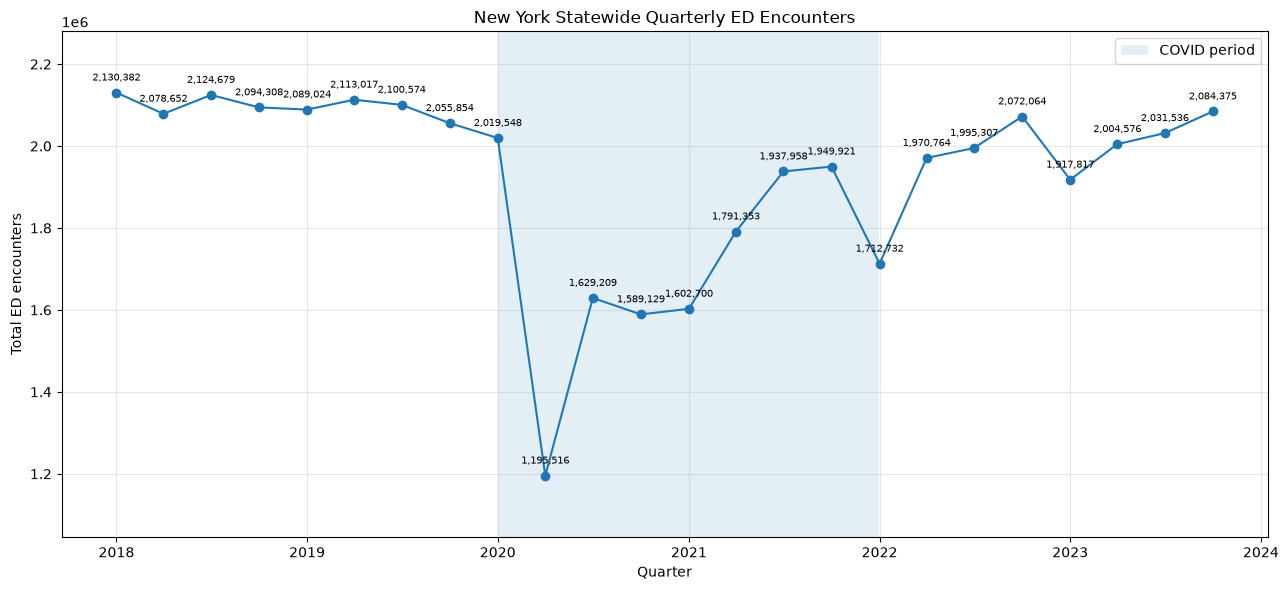

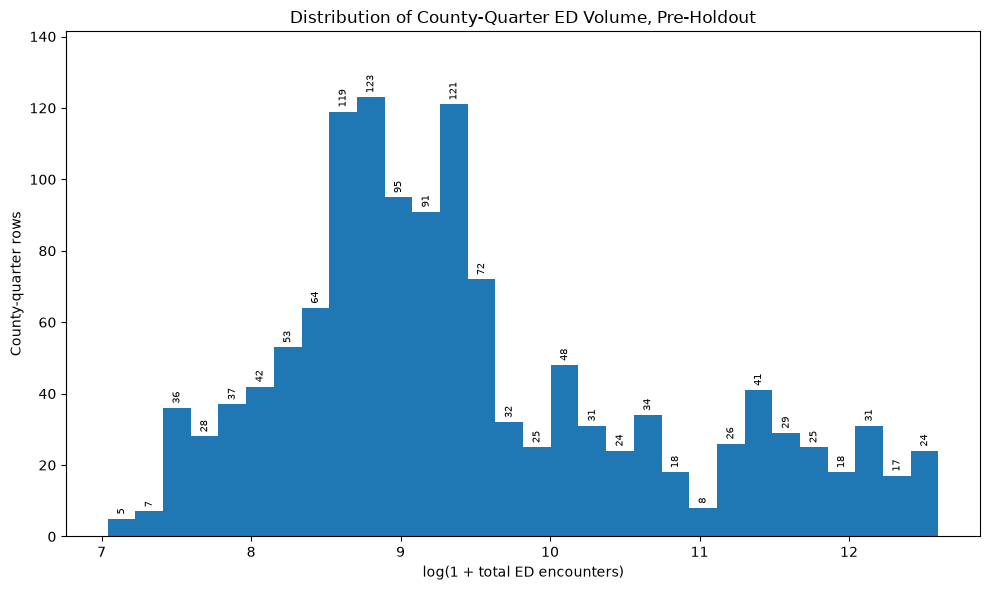

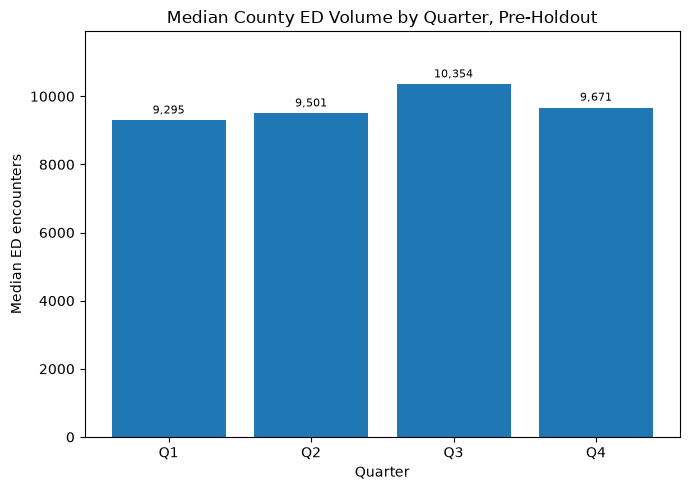

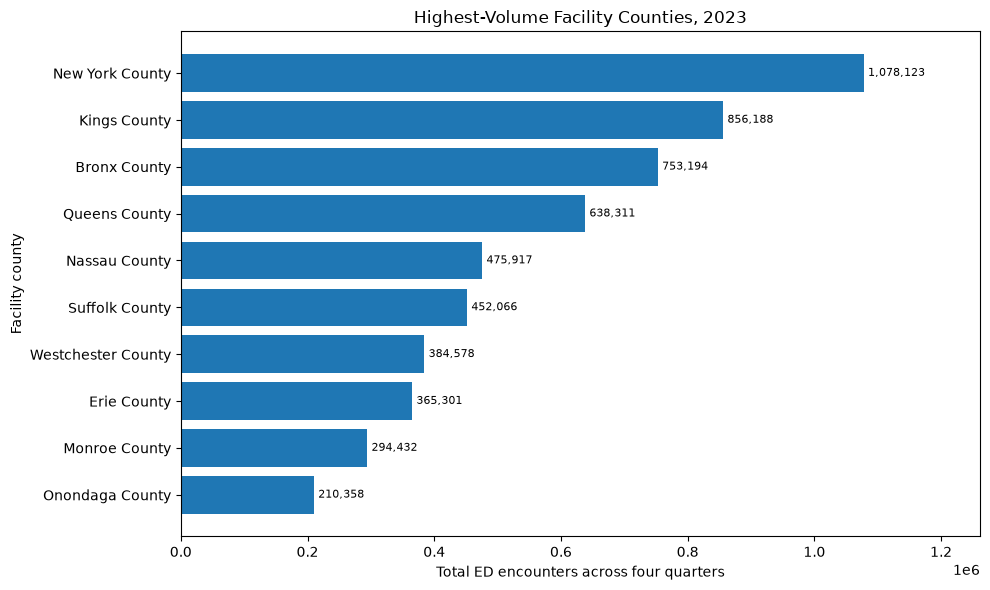

In [7]:
pre_holdout_eda = quarterly_panel.loc[
    quarterly_panel["year"] < HOLDOUT_YEAR
].copy()

if facility_raw is not None and {"facility_name", "quarter", "year", TARGET}.issubset(facility_raw.columns):
    statewide = facility_raw.loc[
        facility_raw["facility_name"].astype(str).str.strip().str.casefold().eq("statewide")
        & facility_raw["quarter"].astype(str).str.upper().isin(["Q1", "Q2", "Q3", "Q4"])
    ].copy()
    statewide["year"] = to_num(statewide["year"])
    statewide["quarter_num"] = statewide["quarter"].str[-1].astype(int)
    statewide[TARGET] = to_num(statewide[TARGET])
else:
    # Fallback when raw statewide summary rows are unavailable.
    statewide = (
        quarterly_panel.groupby(["year", "quarter", "quarter_num"], as_index=False)[TARGET]
        .sum()
    )

statewide["period"] = pd.PeriodIndex(
    year=statewide["year"].astype(int),
    quarter=statewide["quarter_num"].astype(int),
    freq="Q",
).to_timestamp()
statewide = statewide.loc[statewide["year"] < HOLDOUT_YEAR].sort_values("period")

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(statewide["period"], statewide[TARGET], marker="o")
ax.axvspan(
    pd.Timestamp("2020-01-01"),
    pd.Timestamp("2021-12-31"),
    alpha=0.12,
    label="COVID period",
)
add_line_value_labels(
    ax,
    statewide["period"],
    statewide[TARGET],
    formatter=format_count,
    fontsize=7,
)
ax.set_title("New York Statewide Quarterly ED Encounters")
ax.set_xlabel("Quarter")
ax.set_ylabel("Total ED encounters")
ax.grid(alpha=0.3)
ax.legend()
ax.margins(y=0.16)
fig.tight_layout()
fig.savefig(IMAGE_DIR / "statewide_trend.png", dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
hist_counts, hist_bins, hist_patches = ax.hist(
    np.log1p(pre_holdout_eda[TARGET].dropna()),
    bins=30,
)
add_histogram_count_labels(ax, hist_patches, fontsize=7)
ax.set_title("Distribution of County-Quarter ED Volume, Pre-Holdout")
ax.set_xlabel("log(1 + total ED encounters)")
ax.set_ylabel("County-quarter rows")
ax.margins(y=0.15)
fig.tight_layout()
fig.savefig(IMAGE_DIR / "target_distribution_log.png", dpi=200, bbox_inches="tight")
plt.show()

seasonality = (
    pre_holdout_eda
    .groupby("quarter_num")[TARGET]
    .median()
    .reindex([1, 2, 3, 4])
)

fig, ax = plt.subplots(figsize=(7, 5))
seasonality_bars = ax.bar(
    ["Q1", "Q2", "Q3", "Q4"],
    seasonality.values,
)
add_bar_value_labels(
    ax,
    seasonality_bars,
    formatter=format_count,
)
ax.set_title("Median County ED Volume by Quarter, Pre-Holdout")
ax.set_xlabel("Quarter")
ax.set_ylabel("Median ED encounters")
ax.margins(y=0.15)
fig.tight_layout()
fig.savefig(IMAGE_DIR / "seasonality.png", dpi=200, bbox_inches="tight")
plt.show()

latest_descriptive_year = int(pre_holdout_eda["year"].max())
top_counties = (
    pre_holdout_eda.loc[pre_holdout_eda["year"].eq(latest_descriptive_year)]
    .groupby("county_name")[TARGET]
    .sum()
    .nlargest(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 6))
top_county_bars = ax.barh(top_counties.index, top_counties.values)
add_bar_value_labels(
    ax,
    top_county_bars,
    formatter=format_count,
    horizontal=True,
)
ax.set_title(f"Highest-Volume Facility Counties, {latest_descriptive_year}")
ax.set_xlabel("Total ED encounters across four quarters")
ax.set_ylabel("Facility county")
ax.set_xlim(right=top_counties.max() * 1.17)
fig.tight_layout()
fig.savefig(IMAGE_DIR / "top_counties.png", dpi=200, bbox_inches="tight")
plt.show()


### EDA interpretation note

The pre-holdout statewide series was stable near two million encounters per quarter before the pandemic, fell sharply during the 2020 disruption, and then recovered toward its earlier range. The log-scale histogram is used only to display the large difference between small and large facility counties; the forecasting target remains raw encounter counts.

Median county volume is highest in Q3, but the seasonal difference is modest relative to the much larger differences between counties. The highest-volume chart is based on **facility location** and four-quarter totals, not unique patients or county-of-residence utilization. A county with many major hospitals can therefore have more facility encounters than its resident population alone would suggest.


## 12 · Demographic and weather relationships

Raw encounter volume is appropriate for staffing and capacity planning. The two-year-lag population-standardized value is a descriptive **facility-location proxy**, not a resident utilization rate.

Weather relationships use the change from the same quarter in the previous year. This reduces the dominance of stable county-size differences.


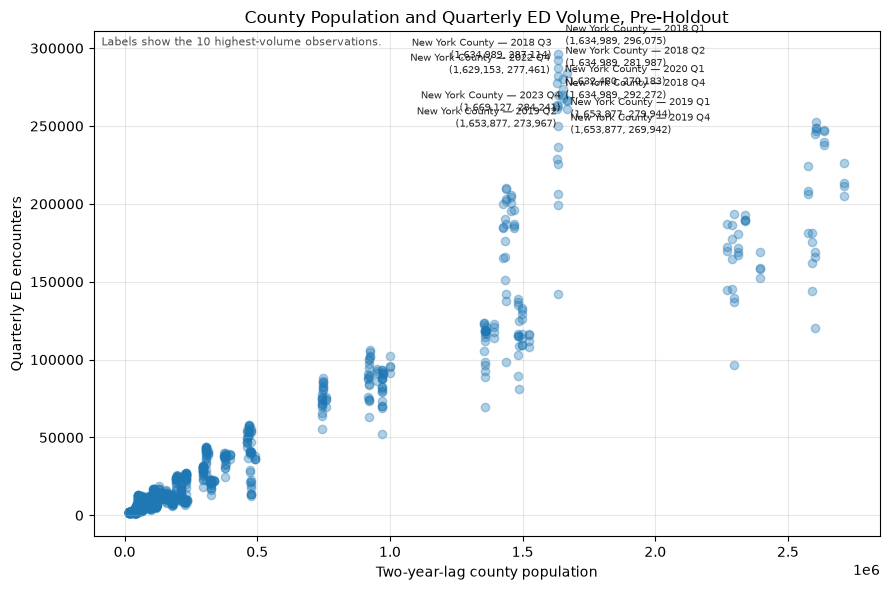

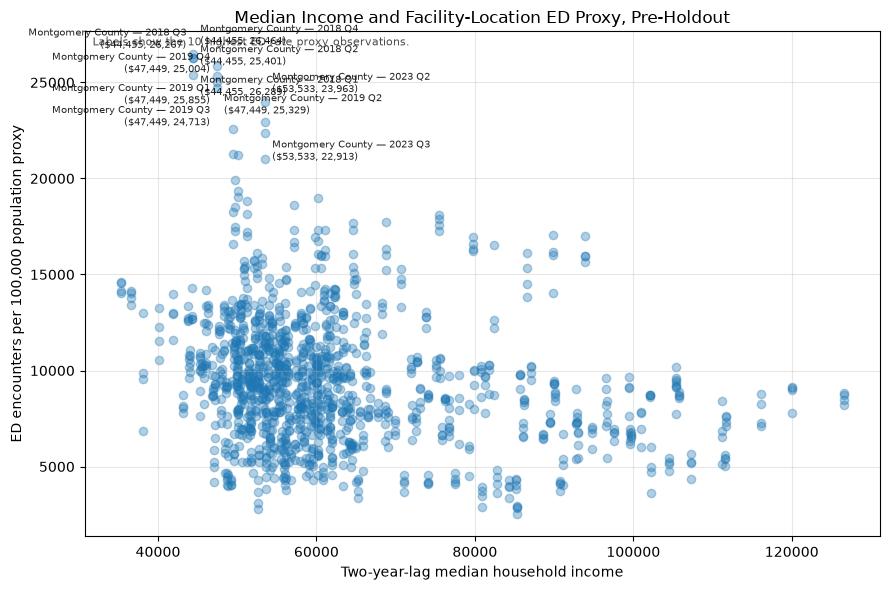

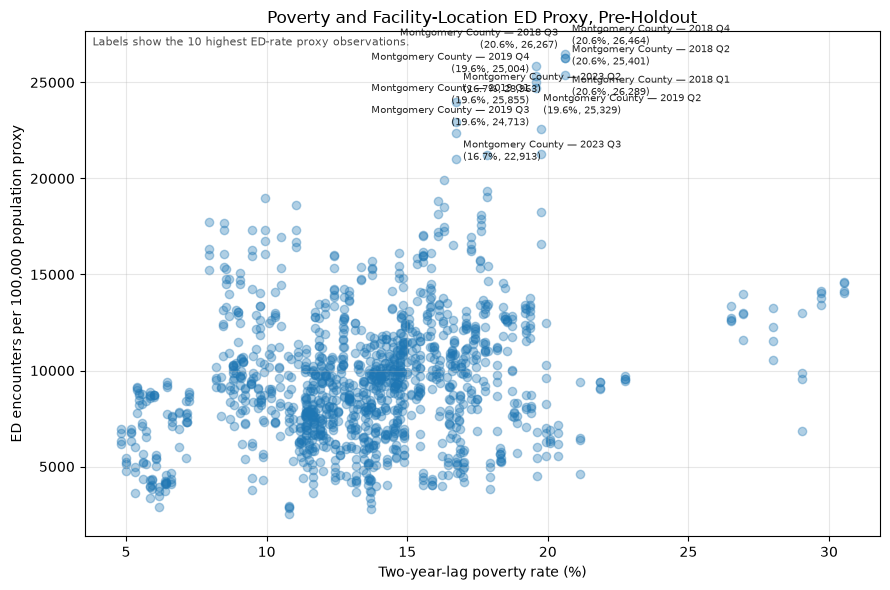

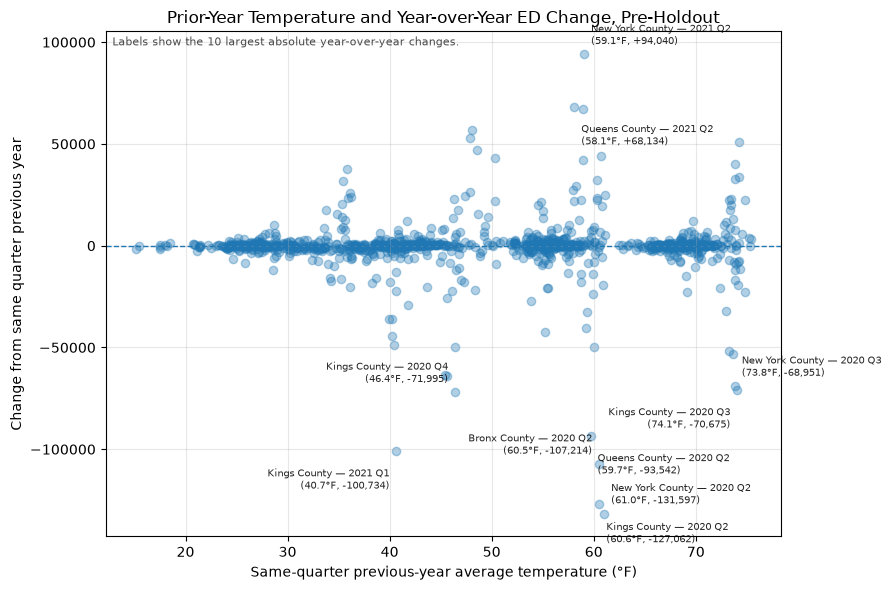

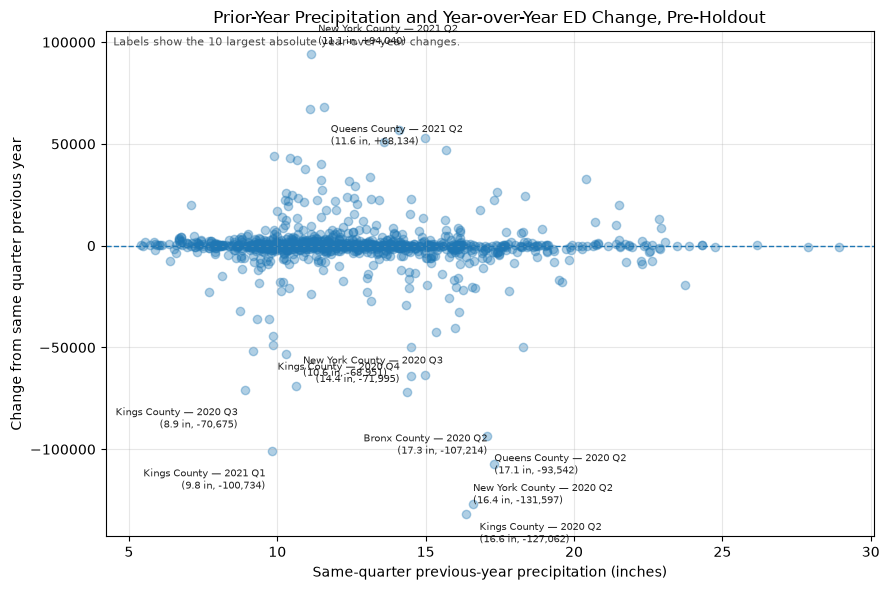

,facility_ed_encounters_per_100k_proxy,acs_lag2_median_income,acs_lag2_poverty_rate,acs_lag2_pct_under5,acs_lag2_pct_65plus,year_over_year_change,weather_lag4_tavg_mean,weather_lag4_precip_total,weather_lag4_snowfall_total
facility_ed_encounters_per_100k_proxy,1.000,-0.274,0.260,-0.032,0.074,0.273,0.015,-0.009,-0.015
acs_lag2_median_income,-0.274,1.000,-0.703,-0.080,-0.172,0.079,0.129,-0.036,-0.128
acs_lag2_poverty_rate,0.260,-0.703,1.000,0.212,-0.163,-0.023,-0.048,0.093,0.048
acs_lag2_pct_under5,-0.032,-0.080,0.212,1.000,-0.396,0.014,0.087,0.053,-0.087
acs_lag2_pct_65plus,0.074,-0.172,-0.163,-0.396,1.000,0.047,-0.093,-0.082,0.091
year_over_year_change,0.273,0.079,-0.023,0.014,0.047,1.000,0.063,-0.119,-0.031
weather_lag4_tavg_mean,0.015,0.129,-0.048,0.087,-0.093,0.063,1.000,0.163,-0.954
weather_lag4_precip_total,-0.009,-0.036,0.093,0.053,-0.082,-0.119,0.163,1.000,-0.107
weather_lag4_snowfall_total,-0.015,-0.128,0.048,-0.087,0.091,-0.031,-0.954,-0.107,1.000


In [8]:
eda_data = quarterly_panel.loc[
    quarterly_panel["year"] < HOLDOUT_YEAR
].copy()
eda_data["observation_label"] = (
    eda_data["county_name"].astype(str)
    + " — "
    + eda_data["year"].astype(int).astype(str)
    + " "
    + eda_data["quarter"].astype(str)
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(eda_data["acs_lag2_population"], eda_data[TARGET], alpha=0.35)
add_selected_scatter_labels(
    ax,
    eda_data,
    x_column="acs_lag2_population",
    y_column=TARGET,
    label_column="observation_label",
    n_labels=10,
    x_formatter=format_count,
    y_formatter=format_count,
    note="Labels show the 10 highest-volume observations.",
)
ax.set_title("County Population and Quarterly ED Volume, Pre-Holdout")
ax.set_xlabel("Two-year-lag county population")
ax.set_ylabel("Quarterly ED encounters")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(IMAGE_DIR / "population_vs_volume.png", dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    eda_data["acs_lag2_median_income"],
    eda_data["facility_ed_encounters_per_100k_proxy"],
    alpha=0.35,
)
add_selected_scatter_labels(
    ax,
    eda_data,
    x_column="acs_lag2_median_income",
    y_column="facility_ed_encounters_per_100k_proxy",
    label_column="observation_label",
    n_labels=10,
    x_formatter=lambda value: f"${value:,.0f}",
    y_formatter=format_count,
    note="Labels show the 10 highest ED-rate proxy observations.",
)
ax.set_title("Median Income and Facility-Location ED Proxy, Pre-Holdout")
ax.set_xlabel("Two-year-lag median household income")
ax.set_ylabel("ED encounters per 100,000 population proxy")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(IMAGE_DIR / "income_vs_ed_proxy.png", dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    eda_data["acs_lag2_poverty_rate"],
    eda_data["facility_ed_encounters_per_100k_proxy"],
    alpha=0.35,
)
add_selected_scatter_labels(
    ax,
    eda_data,
    x_column="acs_lag2_poverty_rate",
    y_column="facility_ed_encounters_per_100k_proxy",
    label_column="observation_label",
    n_labels=10,
    x_formatter=lambda value: f"{value:.1f}%",
    y_formatter=format_count,
    note="Labels show the 10 highest ED-rate proxy observations.",
)
ax.set_title("Poverty and Facility-Location ED Proxy, Pre-Holdout")
ax.set_xlabel("Two-year-lag poverty rate (%)")
ax.set_ylabel("ED encounters per 100,000 population proxy")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(IMAGE_DIR / "poverty_vs_ed_proxy.png", dpi=200, bbox_inches="tight")
plt.show()

eda_data["year_over_year_change"] = eda_data[TARGET] - eda_data["target_lag4"]

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    eda_data["weather_lag4_tavg_mean"],
    eda_data["year_over_year_change"],
    alpha=0.35,
)
ax.axhline(0, linestyle="--", linewidth=1)
add_selected_scatter_labels(
    ax,
    eda_data,
    x_column="weather_lag4_tavg_mean",
    y_column="year_over_year_change",
    label_column="observation_label",
    score_column="year_over_year_change",
    n_labels=10,
    x_formatter=lambda value: f"{value:.1f}°F",
    y_formatter=lambda value: f"{value:+,.0f}",
    note="Labels show the 10 largest absolute year-over-year changes.",
)
ax.set_title("Prior-Year Temperature and Year-over-Year ED Change, Pre-Holdout")
ax.set_xlabel("Same-quarter previous-year average temperature (°F)")
ax.set_ylabel("Change from same quarter previous year")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(IMAGE_DIR / "temperature_vs_ed_change.png", dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    eda_data["weather_lag4_precip_total"],
    eda_data["year_over_year_change"],
    alpha=0.35,
)
ax.axhline(0, linestyle="--", linewidth=1)
add_selected_scatter_labels(
    ax,
    eda_data,
    x_column="weather_lag4_precip_total",
    y_column="year_over_year_change",
    label_column="observation_label",
    score_column="year_over_year_change",
    n_labels=10,
    x_formatter=lambda value: f"{value:.1f} in",
    y_formatter=lambda value: f"{value:+,.0f}",
    note="Labels show the 10 largest absolute year-over-year changes.",
)
ax.set_title("Prior-Year Precipitation and Year-over-Year ED Change, Pre-Holdout")
ax.set_xlabel("Same-quarter previous-year precipitation (inches)")
ax.set_ylabel("Change from same quarter previous year")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(IMAGE_DIR / "precipitation_vs_ed_change.png", dpi=200, bbox_inches="tight")
plt.show()

relationship_columns = [
    "facility_ed_encounters_per_100k_proxy",
    "acs_lag2_median_income",
    "acs_lag2_poverty_rate",
    "acs_lag2_pct_under5",
    "acs_lag2_pct_65plus",
    "year_over_year_change",
    "weather_lag4_tavg_mean",
    "weather_lag4_precip_total",
    "weather_lag4_snowfall_total",
]

relationship_table = (
    eda_data[relationship_columns]
    .corr(method="spearman")
    .round(3)
)

display(relationship_table)
relationship_table.to_csv(PROCESSED_DIR / "eda_spearman_correlations.csv")


### Demographic and weather interpretation note

Two-year-lag county population has a strong positive relationship with raw quarterly encounter volume, as expected for an operational demand target. New York County sits above similarly populated counties because the numerator follows facility location and includes patients who may live elsewhere.

The income and poverty plots do not show a clean linear relationship. Montgomery County repeatedly appears among the largest per-capita proxy values, but this proxy combines facility-location encounters with resident population and must not be interpreted as a resident ED-use rate or as evidence that income or poverty causes ED demand.

The temperature and precipitation plots show no clear monotonic relationship with year-over-year encounter change. The largest changes are concentrated in large New York City facility counties and pandemic/recovery periods, indicating that broad time shocks can dominate weather in these descriptive plots. Weather value should therefore be judged through out-of-time validation and SHAP, not from these scatterplots alone.


## 13 · Correlation and multicollinearity

The heatmap is descriptive. VIF is used to identify linear redundancy before modeling. `target_roll4` is retained in the analytical table for interpretation but excluded from the candidate feature set because it is an exact average of `target_lag1` through `target_lag4`.

**Task 3 deliverable:** labeled visualizations and written interpretation covering quarterly seasonality, geographic variation, volume-versus-population caveats, predictor relationships, and potential leakage or redundancy.


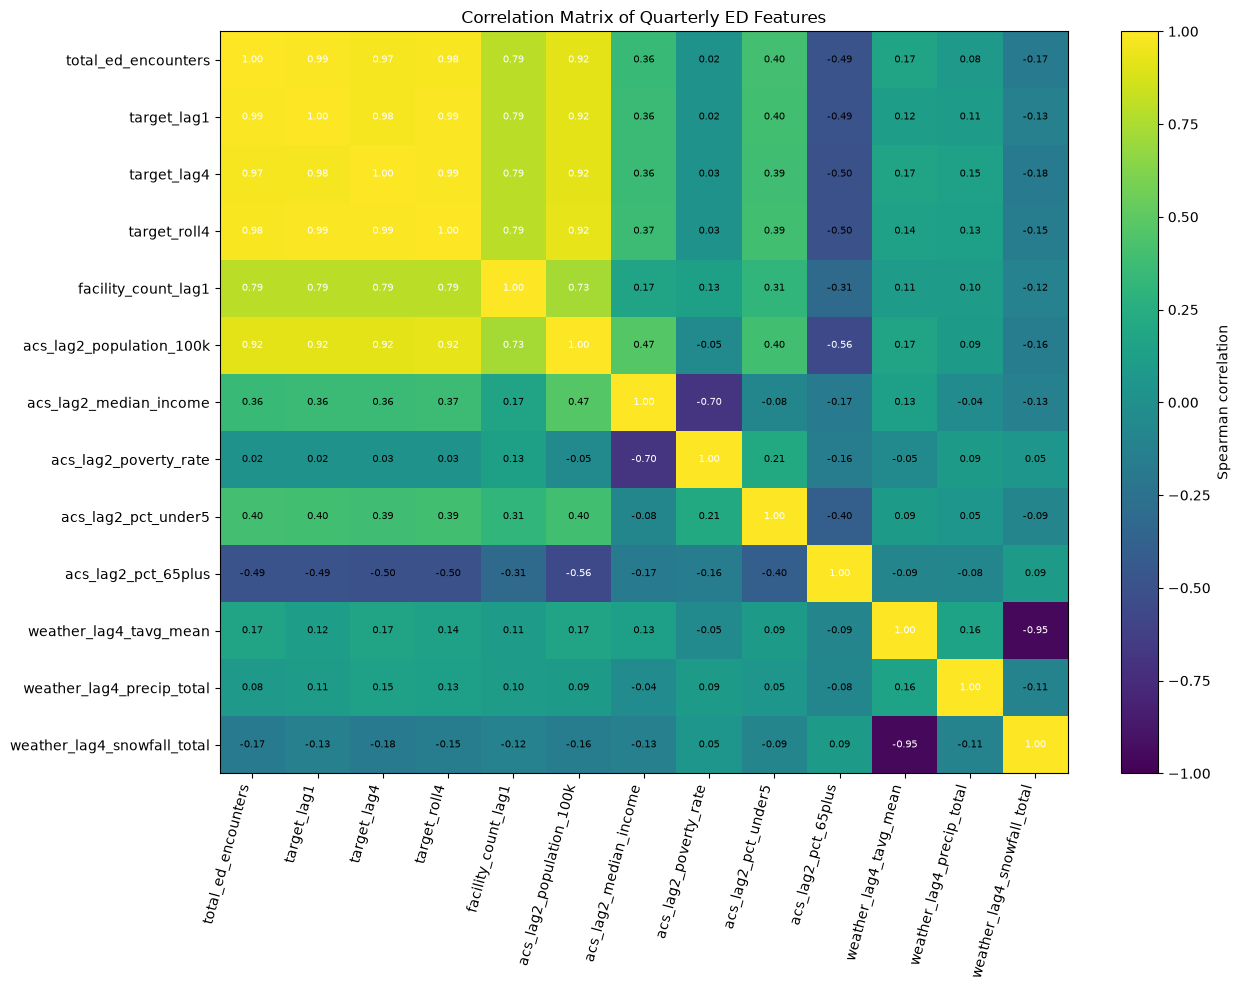

,feature,VIF
2,target_lag3,60.33
1,target_lag2,59.66
0,target_lag1,45.83
3,target_lag4,45.24
5,acs_lag2_population_100k,9.90
4,facility_count_lag1,7.84
10,weather_lag4_tavg_mean,5.47
12,weather_lag4_snowfall_total,5.35
6,acs_lag2_median_income,3.54
7,acs_lag2_poverty_rate,3.46


In [9]:
correlation_columns = [
    TARGET,
    "target_lag1",
    "target_lag4",
    "target_roll4",
    "facility_count_lag1",
    "acs_lag2_population_100k",
    "acs_lag2_median_income",
    "acs_lag2_poverty_rate",
    "acs_lag2_pct_under5",
    "acs_lag2_pct_65plus",
    "weather_lag4_tavg_mean",
    "weather_lag4_precip_total",
    "weather_lag4_snowfall_total",
]

correlation_matrix = eda_data[correlation_columns].corr(method="spearman")

fig, ax = plt.subplots(figsize=(13, 10))
correlation_image = ax.imshow(
    correlation_matrix,
    aspect="auto",
    vmin=-1,
    vmax=1,
)
fig.colorbar(correlation_image, ax=ax, label="Spearman correlation")
ax.set_xticks(range(len(correlation_columns)))
ax.set_xticklabels(
    correlation_columns,
    rotation=75,
    ha="right",
)
ax.set_yticks(range(len(correlation_columns)))
ax.set_yticklabels(correlation_columns)

for row_index in range(correlation_matrix.shape[0]):
    for column_index in range(correlation_matrix.shape[1]):
        value = correlation_matrix.iloc[row_index, column_index]
        if pd.isna(value):
            continue
        ax.text(
            column_index,
            row_index,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=7,
            color="white" if abs(value) >= 0.55 else "black",
        )

ax.set_title("Correlation Matrix of Quarterly ED Features")
fig.tight_layout()
fig.savefig(IMAGE_DIR / "correlation_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()


def calculate_vif(frame, columns):
    complete = frame[columns].dropna().astype(float)
    rows = []

    for feature in columns:
        other_features = [column for column in columns if column != feature]
        model = LinearRegression().fit(
            complete[other_features],
            complete[feature],
        )
        r_squared = model.score(
            complete[other_features],
            complete[feature],
        )
        vif = np.inf if r_squared >= 0.999999 else 1 / (1 - r_squared)
        rows.append({"feature": feature, "VIF": vif})

    return pd.DataFrame(rows).sort_values("VIF", ascending=False)


vif_columns = [
    "target_lag1",
    "target_lag2",
    "target_lag3",
    "target_lag4",
    "facility_count_lag1",
    "acs_lag2_population_100k",
    "acs_lag2_median_income",
    "acs_lag2_poverty_rate",
    "acs_lag2_pct_under5",
    "acs_lag2_pct_65plus",
    "weather_lag4_tavg_mean",
    "weather_lag4_precip_total",
    "weather_lag4_snowfall_total",
]

vif_table = calculate_vif(eda_data, vif_columns)
display(vif_table.round(2))
vif_table.to_csv(PROCESSED_DIR / "multicollinearity_vif.csv", index=False)


### Correlation interpretation note

The target is strongly associated with recent demand history and county population. This is expected: county scale is persistent, and adjacent quarterly volumes are highly related. These correlations are descriptive rather than causal.

The very strong negative relationship between temperature and snowfall indicates redundant seasonal information. High correlations among `target_lag1`, `target_lag4`, and `target_roll4` also mean that feature importance can be shared across related variables. `target_roll4` is excluded because it is constructed directly from the four lag variables; remaining predictors are handled through fold-specific selection and regularization rather than being removed solely because of pairwise correlation.


# Phase 5 — Feature Engineering, Selection, and Modeling

## Task 4 — Feature Engineering & Selection

The candidate pool combines demand-history, demographic, weather, calendar, COVID-period, facility-history, and geographic predictors. Feature definitions remain quarterly, and all selection steps are fitted only on the relevant training period.


## 14 · Task 4 leakage-safe predictor set

Excluded from modeling:

- current-quarter weather;
- current-quarter encounter components and current-quarter facility count;
- numeric year;
- the descriptive per-capita proxy;
- `target_roll4`, because it is an exact linear combination of the four lag columns.

The two geography indicators use upstate as the reference group, so no redundant third region dummy is added. Tree models do not extrapolate a numeric time trend reliably; demand history carries the level, while quarter and COVID flags are retained only when selected from training data.


In [12]:
# ============================================================
# Candidate modeling features
# ============================================================
#
# Column names are lowercase because the SQL-export loading
# cell normalizes all Oracle / CSV headers to lowercase.
# ============================================================


# ------------------------------------------------------------
# 1. Demographic features
# ------------------------------------------------------------

DEMOGRAPHIC_FEATURES = [
    "acs_lag2_population_100k",
    "acs_lag2_median_income",
    "acs_lag2_poverty_rate",
    "acs_lag2_pct_under5",
    "acs_lag2_pct_65plus",
]


# ------------------------------------------------------------
# 2. Prior-year weather features
# ------------------------------------------------------------

WEATHER_FEATURES = [
    "weather_lag4_tavg_mean",
    "weather_lag4_precip_total",
    "weather_lag4_snowfall_total",
    "weather_lag4_hot_days",
    "weather_lag4_freeze_days",
    "weather_lag4_wet_days",
]


# ------------------------------------------------------------
# 3. Demand-history features
# ------------------------------------------------------------

HISTORY_FEATURES = [
    "target_lag1",
    "target_lag2",
    "target_lag3",
    "target_lag4",
    "facility_count_lag1",
]


# ------------------------------------------------------------
# 4. Calendar / pandemic features
# ------------------------------------------------------------
#
# Q1 is the reference quarter, so only Q2-Q4 dummy
# variables are included.
#
# NOTE:
# The SQL aliases were originally quarter_Q2, quarter_Q3,
# and quarter_Q4, but the notebook normalizes all imported
# column names to lowercase.
# ------------------------------------------------------------

CALENDAR_FEATURES = [
    "quarter_q2",
    "quarter_q3",
    "quarter_q4",
    "is_covid",
    "post_covid",
]


# ------------------------------------------------------------
# 5. Geography features
# ------------------------------------------------------------

GEOGRAPHY_FEATURES = [
    "lat",
    "lon",
    "is_nyc",
    "is_downstate_non_nyc",
]


# ------------------------------------------------------------
# 6. Complete candidate feature list
# ------------------------------------------------------------

FEATURE_COLUMNS = (
    DEMOGRAPHIC_FEATURES
    + WEATHER_FEATURES
    + HISTORY_FEATURES
    + CALENDAR_FEATURES
    + GEOGRAPHY_FEATURES
)


# ------------------------------------------------------------
# 7. Feature-group labels
# ------------------------------------------------------------

FEATURE_GROUPS = {
    **{
        feature: "Demographics"
        for feature in DEMOGRAPHIC_FEATURES
    },

    **{
        feature: "Prior-year weather"
        for feature in WEATHER_FEATURES
    },

    **{
        feature: "Demand history"
        for feature in HISTORY_FEATURES
    },

    **{
        feature: "Calendar"
        for feature in CALENDAR_FEATURES
    },

    **{
        feature: "Geography"
        for feature in GEOGRAPHY_FEATURES
    },
}


# ------------------------------------------------------------
# 8. Validate feature names before modeling
# ------------------------------------------------------------

missing_features = [
    feature
    for feature in FEATURE_COLUMNS
    if feature not in quarterly_panel.columns
]

if missing_features:
    raise KeyError(
        "The following modeling features are missing from "
        "quarterly_panel:\n"
        + "\n".join(
            f"- {feature}"
            for feature in missing_features
        )
    )


# ------------------------------------------------------------
# 9. Create feature dictionary
# ------------------------------------------------------------

feature_dictionary = pd.DataFrame(
    {
        "feature": FEATURE_COLUMNS,

        "group": [
            FEATURE_GROUPS[feature]
            for feature in FEATURE_COLUMNS
        ],
    }
)


display(
    feature_dictionary
)


feature_dictionary.to_csv(
    REPORT_DIR / "feature_dictionary.csv",
    index=False,
)


print(
    "Candidate predictors:",
    len(FEATURE_COLUMNS),
)

print(
    "Feature-name validation passed."
)

,feature,group
0,acs_lag2_population_100k,Demographics
1,acs_lag2_median_income,Demographics
2,acs_lag2_poverty_rate,Demographics
3,acs_lag2_pct_under5,Demographics
4,acs_lag2_pct_65plus,Demographics
5,weather_lag4_tavg_mean,Prior-year weather
6,weather_lag4_precip_total,Prior-year weather
7,weather_lag4_snowfall_total,Prior-year weather
8,weather_lag4_hot_days,Prior-year weather
9,weather_lag4_freeze_days,Prior-year weather


Candidate predictors: 25
Feature-name validation passed.


## 15 · Task 4 final holdout and model-ready rows

The final holdout is one complete calendar year containing four sequential one-quarter-ahead evaluation quarters. Model selection and tuning use only earlier quarters.


In [13]:
model_ready = quarterly_panel.dropna(
    subset=FEATURE_COLUMNS + [TARGET]
).copy()

holdout_train = model_ready.loc[
    model_ready["year"] <= TRAIN_END_YEAR
].copy()

holdout_test = model_ready.loc[
    model_ready["year"] == HOLDOUT_YEAR
].copy()

if holdout_train.empty or holdout_test.empty:
    raise ValueError(
        "The model-ready training or holdout table is empty."
    )

holdout_quarters = sorted(
    holdout_test["quarter"].unique()
)

if holdout_quarters != [
    "Q1",
    "Q2",
    "Q3",
    "Q4",
]:
    raise ValueError(
        "The final holdout does not contain all four quarters: "
        f"{holdout_quarters}"
    )

holdout_model_coverage = (
    holdout_test
    .groupby("quarter")["fips"]
    .nunique()
    .reindex(
        ["Q1", "Q2", "Q3", "Q4"],
        fill_value=0,
    )
)

if (
    holdout_model_coverage
    .lt(minimum_complete_count)
    .any()
):
    raise ValueError(
        "The model-ready holdout has insufficient "
        "county coverage: "
        f"{holdout_model_coverage.to_dict()}"
    )

print(
    "Training years:",
    int(holdout_train["year"].min()),
    "to",
    TRAIN_END_YEAR,
)

print(
    "Final holdout year:",
    HOLDOUT_YEAR,
)

print(
    "Training rows:",
    len(holdout_train),
)

print(
    "Holdout rows:",
    len(holdout_test),
)

print(
    "Holdout quarters:",
    holdout_quarters,
)

print(
    "Model-ready holdout county coverage:"
)

display(
    holdout_model_coverage.to_frame(
        "counties"
    )
)

Training years: 2019 to 2023
Final holdout year: 2024
Training rows: 1088
Holdout rows: 212
Holdout quarters: ['Q1', 'Q2', 'Q3', 'Q4']
Model-ready holdout county coverage:


,counties
quarter,
Q1,53
Q2,53
Q3,53
Q4,53


## 16 · Task 4 visible, leakage-safe feature selection

`SelectKBest` with F-regression is used as a transparent screening step. It is fitted on the training period only and refitted inside every rolling fold.

Separate feature lists are learned for the level target and the change-from-seasonal-persistence target. Forward and backward stepwise selection are not used because the lag predictors are correlated, stepwise subsets are unstable across time, and stepwise procedures are not naturally aligned with the nonlinear candidate models.


In [14]:
DEFAULT_FEATURE_SELECTION_K = 15
FEATURE_SELECTION_K_OPTIONS = [10, 15, 20]


def target_for_mode(frame, target_mode):
    if target_mode == "change":
        # Quarterly equivalent of "change from last year."
        return frame[TARGET] - frame["target_lag4"]
    return frame[TARGET]


def select_features(
    train_frame,
    target_mode,
    k=DEFAULT_FEATURE_SELECTION_K,
):
    usable_features = [
        feature
        for feature in FEATURE_COLUMNS
        if train_frame[feature].nunique(dropna=True) > 1
    ]

    if not usable_features:
        raise ValueError("No non-constant candidate features are available.")

    selector = SelectKBest(
        score_func=f_regression,
        k=min(int(k), len(usable_features)),
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        selector.fit(
            train_frame[usable_features],
            target_for_mode(train_frame, target_mode),
        )

    report = pd.DataFrame({
        "feature": usable_features,
        "feature_group": [
            FEATURE_GROUPS[feature]
            for feature in usable_features
        ],
        "f_score": selector.scores_,
        "p_value": selector.pvalues_,
        "selected": selector.get_support(),
    })

    report["f_score"] = report["f_score"].replace(
        [np.inf, -np.inf],
        np.nan,
    )
    report = report.sort_values(
        ["selected", "f_score"],
        ascending=[False, False],
    ).reset_index(drop=True)
    report["rank"] = np.arange(1, len(report) + 1)

    selected_features = report.loc[
        report["selected"],
        "feature",
    ].tolist()

    return selected_features, selector, report


level_features, _, level_feature_report = select_features(
    holdout_train,
    "level",
)
change_features, _, change_feature_report = select_features(
    holdout_train,
    "change",
)

print("Default feature count:", DEFAULT_FEATURE_SELECTION_K)
print("Feature counts considered during tuning:", FEATURE_SELECTION_K_OPTIONS)
print("Level-target feature screening:")
display(level_feature_report.head(20).round(4))

print("Change-from-seasonal-persistence feature screening:")
display(change_feature_report.head(20).round(4))

level_feature_report.to_csv(
    PROCESSED_DIR / "feature_selection_level.csv",
    index=False,
)
change_feature_report.to_csv(
    PROCESSED_DIR / "feature_selection_change.csv",
    index=False,
)


Default feature count: 15
Feature counts considered during tuning: [10, 15, 20]
Level-target feature screening:


,feature,feature_group,f_score,p_value,selected,rank
0,target_lag1,Demand history,37917.1553,0.0000,True,1
1,target_lag2,Demand history,28784.9411,0.0000,True,2
2,target_lag3,Demand history,22665.7048,0.0000,True,3
3,target_lag4,Demand history,18816.1377,0.0000,True,4
4,acs_lag2_population_100k,Demographics,7117.0728,0.0000,True,5
5,facility_count_lag1,Demand history,6002.1971,0.0000,True,6
6,is_nyc,Geography,1497.0881,0.0000,True,7
7,lat,Geography,574.3873,0.0000,True,8
8,acs_lag2_pct_65plus,Demographics,245.5369,0.0000,True,9
9,acs_lag2_pct_under5,Demographics,127.9355,0.0000,True,10


Change-from-seasonal-persistence feature screening:


,feature,feature_group,f_score,p_value,selected,rank
0,target_lag4,Demand history,47.2154,0.0000,True,1
1,is_covid,Calendar,23.5557,0.0000,True,2
2,post_covid,Calendar,19.4153,0.0000,True,3
3,target_lag3,Demand history,17.9314,0.0000,True,4
4,weather_lag4_wet_days,Prior-year weather,13.3720,0.0003,True,5
5,target_lag2,Demand history,8.6619,0.0033,True,6
6,acs_lag2_population_100k,Demographics,6.7544,0.0095,True,7
7,is_nyc,Geography,6.0562,0.0140,True,8
8,acs_lag2_pct_65plus,Demographics,4.6212,0.0318,True,9
9,facility_count_lag1,Demand history,4.4462,0.0352,True,10


### Task 4 note

Feature selection is target-specific and leakage-safe. The fixed holdout feature lists are learned from pre-holdout rows only. During rolling-origin validation, the selector is refitted inside each fold using only quarters earlier than the validation quarter, and fold-constant predictors are removed before F-scoring.


## Model Selection and Development

### Task 5 — Persistence baselines, metrics, and compact candidate set

The main metric is MAE. Skill is the fraction of persistence MAE removed:

`skill = 1 - model_MAE / benchmark_MAE`

Positive skill means the model beats the benchmark. WAPE expresses total absolute error as a percentage of total observed encounter volume, so lower values are better. Pooled R² is retained but treated as secondary because county volumes differ greatly in scale.

After discussion with the professor, XGBoost replaces Hist Gradient Boosting. Each retained model family is evaluated under both target formulations so the comparison is balanced:

- Ridge — level;
- Ridge — change from seasonal persistence;
- Random Forest — level;
- Random Forest — change from seasonal persistence;
- XGBoost — level;
- XGBoost — change from seasonal persistence.

For the change formulation, the target is current encounters minus `target_lag4`. The predicted change is added back to `target_lag4` to reconstruct the encounter level. This directly tests whether two-year-lag demographics, prior-year weather, geography, and recent demand history improve on carrying the same quarter from the previous year forward.

**Week of July 14 deliverable:** define common evaluation functions, compare all six candidates against the quarterly persistence baselines, and carry the best-supported model family and target formulation into rolling validation.


In [15]:
def regression_metrics(actual, prediction):
    actual = np.asarray(actual)
    prediction = np.asarray(prediction)

    mae = mean_absolute_error(actual, prediction)
    rmse = mean_squared_error(actual, prediction) ** 0.5
    wape = np.abs(actual - prediction).sum() / np.abs(actual).sum()

    return {
        "MAE": mae,
        "RMSE": rmse,
        "WAPE": wape,
        "R2": r2_score(actual, prediction),
    }


def skill_vs(actual, prediction, benchmark):
    model_mae = mean_absolute_error(actual, prediction)
    benchmark_mae = mean_absolute_error(actual, benchmark)

    if benchmark_mae == 0:
        return np.nan

    return 1 - model_mae / benchmark_mae


def change_r2(actual, prediction, reference):
    actual_change = np.asarray(actual) - np.asarray(reference)
    predicted_change = np.asarray(prediction) - np.asarray(reference)

    if np.allclose(actual_change, actual_change[0]):
        return np.nan

    return r2_score(actual_change, predicted_change)


RANDOM_FOREST_BASE = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1,
)

XGBOOST_BASE = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="mae",
    tree_method="hist",
    n_estimators=350,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

CANDIDATE_SPECS = {
    "Ridge — level": {
        "family": "Ridge",
        "target_mode": "level",
        "needs_scaling": True,
        "estimator": Ridge(alpha=1.0),
    },
    "Ridge — change from seasonal persistence": {
        "family": "Ridge",
        "target_mode": "change",
        "needs_scaling": True,
        "estimator": Ridge(alpha=1.0),
    },
    "Random Forest — level": {
        "family": "Random Forest",
        "target_mode": "level",
        "needs_scaling": False,
        "estimator": RANDOM_FOREST_BASE,
    },
    "Random Forest — change from seasonal persistence": {
        "family": "Random Forest",
        "target_mode": "change",
        "needs_scaling": False,
        "estimator": RANDOM_FOREST_BASE,
    },
    "XGBoost — level": {
        "family": "XGBoost",
        "target_mode": "level",
        "needs_scaling": False,
        "estimator": XGBOOST_BASE,
    },
    "XGBoost — change from seasonal persistence": {
        "family": "XGBoost",
        "target_mode": "change",
        "needs_scaling": False,
        "estimator": XGBOOST_BASE,
    },
}


def fit_predict(train_frame, test_frame, spec, features, estimator=None):
    model = clone(
        estimator if estimator is not None
        else spec["estimator"]
    )

    X_train = train_frame[features]
    X_test = test_frame[features]

    scaler = None
    if spec["needs_scaling"]:
        scaler = StandardScaler().fit(X_train)
        X_train_fit = scaler.transform(X_train)
        X_test_fit = scaler.transform(X_test)
    else:
        X_train_fit = X_train
        X_test_fit = X_test

    model.fit(
        X_train_fit,
        target_for_mode(train_frame, spec["target_mode"]),
    )
    component_prediction = model.predict(X_test_fit)

    if spec["target_mode"] == "change":
        level_prediction = (
            test_frame["target_lag4"].to_numpy()
            + component_prediction
        )
    else:
        level_prediction = component_prediction

    return {
        "model": model,
        "scaler": scaler,
        "prediction": np.asarray(level_prediction),
    }


### Week of July 14 deliverable — candidate model set

Ridge, Random Forest, and XGBoost are evaluated under the same complete-quarter rolling-origin design. The machine-learning specification with the lowest mean rolling MAE is carried forward to tuning. The exact winner and comparison paragraph are generated directly from the results in Task 6 so the narrative stays synchronized after rerunning the notebook.


## Week of July 21 — Model Evaluation and Validation

### Task 6 — Explicit rolling-origin validation by complete quarter

A row-based `TimeSeriesSplit` is not appropriate for a county-quarter panel because rows from the same calendar quarter could appear on both sides of a split.

Each expanding-window fold:

- trains on every earlier complete quarter;
- validates on one later complete quarter across counties;
- refits feature selection, scaling, and the model inside the fold;
- reports MAE, RMSE, WAPE, and R² for every model and persistence benchmark;
- compares MAE with both previous-quarter and same-quarter-last-year persistence;
- uses the strongest persistence benchmark for the reported skill score;
- uses mean rolling MAE as the primary model-selection criterion, with R² retained as a secondary diagnostic;
- summarizes stability by validation quarter, calendar quarter, region, and county.

The first eight model-ready quarters establish the initial training history. This section is the formal **through-July-21 validation checkpoint**.


,model,mean_MAE,median_MAE,mean_RMSE,mean_WAPE,mean_R2,median_R2,mean_skill,quarters_beating_benchmark,validation_quarters
0,Previous-quarter persistence,2419.0021,2368.0472,4910.6560,0.0747,0.9890,0.9936,0.0000,0,12
1,XGBoost — level,2991.4430,3228.3370,6146.6547,0.0922,0.9849,0.9893,-0.6446,4,12
2,Random Forest — level,2992.6985,3118.3913,6517.8036,0.0915,0.9836,0.9848,-0.5937,3,12
3,Ridge — level,4174.7616,4084.8372,7061.4176,0.1281,0.9789,0.9843,-1.4298,1,12
4,XGBoost — change from seasonal persistence,4210.7881,2828.9006,9644.6854,0.1297,0.9432,0.9866,-0.9015,3,12
5,Random Forest — change from seasonal persistence,4237.1467,2823.2688,9804.9244,0.1295,0.9473,0.9823,-1.0524,4,12
6,Seasonal persistence,4366.5407,3263.4818,9889.6405,0.1353,0.9528,0.9807,-1.1265,3,12
7,Ridge — change from seasonal persistence,5601.5899,4250.0015,8505.8496,0.1713,0.9685,0.9738,-2.3588,0,12


Selected ML candidate: XGBoost — level
Strongest persistence benchmark: Previous-quarter persistence
XGBoost — level had mean rolling MAE 2,991.4, mean rolling R² 0.985, and mean skill -0.645 versus Previous-quarter persistence. It beat the benchmark in 4 of 12 validation quarters.
Feature-selection stability for the selected ML candidate:


,feature,selected_quarters,selection_rate
0,acs_lag2_median_income,12,1.0
1,acs_lag2_pct_65plus,12,1.0
2,acs_lag2_pct_under5,12,1.0
3,acs_lag2_population_100k,12,1.0
4,acs_lag2_poverty_rate,12,1.0
5,facility_count_lag1,12,1.0
6,is_downstate_non_nyc,12,1.0
7,is_nyc,12,1.0
8,lat,12,1.0
9,lon,12,1.0


Pre-holdout error by region:


,model,region,MAE,mean_residual,rows
0,Previous-quarter persistence,downstate_non_nyc,5845.48,1572.56,48
1,Previous-quarter persistence,nyc,11802.48,3940.08,60
2,Previous-quarter persistence,upstate,1077.32,190.42,544
3,XGBoost — level,downstate_non_nyc,7993.10,3104.85,48
4,XGBoost — level,nyc,13387.49,5044.16,60
5,XGBoost — level,upstate,1399.56,635.19,544


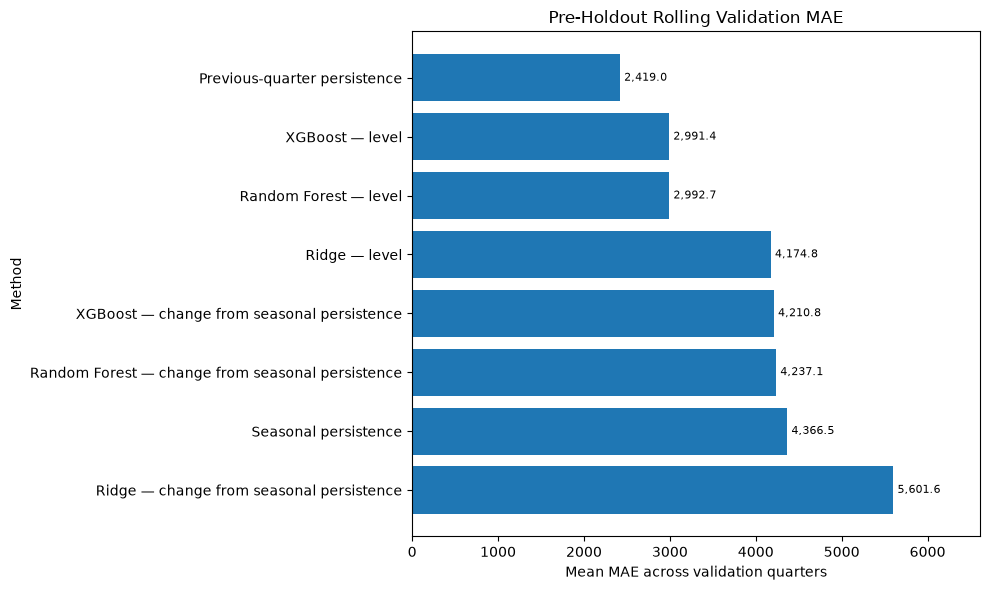

Rolling-origin results for XGBoost — level:


,year,quarter,model_MAE,persistence_MAE,RMSE,WAPE_percent,model_R2,skill
6,2021,Q1,3570.3,2654.0,8714.2,12.69,0.9645,-0.3453
14,2021,Q2,4056.0,3482.6,6477.4,12.82,0.9834,-0.1646
22,2021,Q3,3261.9,2582.8,5583.5,9.56,0.9892,-0.2629
30,2021,Q4,2149.5,2153.3,4864.8,6.29,0.9926,0.0017
38,2022,Q1,4649.8,3781.6,10003.9,15.82,0.9590,-0.2296
46,2022,Q2,3895.5,4349.4,8292.3,11.54,0.9786,0.1044
54,2022,Q3,3194.8,578.9,5847.3,9.37,0.9895,-4.5190
62,2022,Q4,2350.0,1773.4,5194.0,6.64,0.9926,-0.3251
70,2023,Q1,3306.6,3704.1,6729.9,10.15,0.9850,0.1073
78,2023,Q2,1506.4,1507.3,2746.7,4.42,0.9976,0.0006


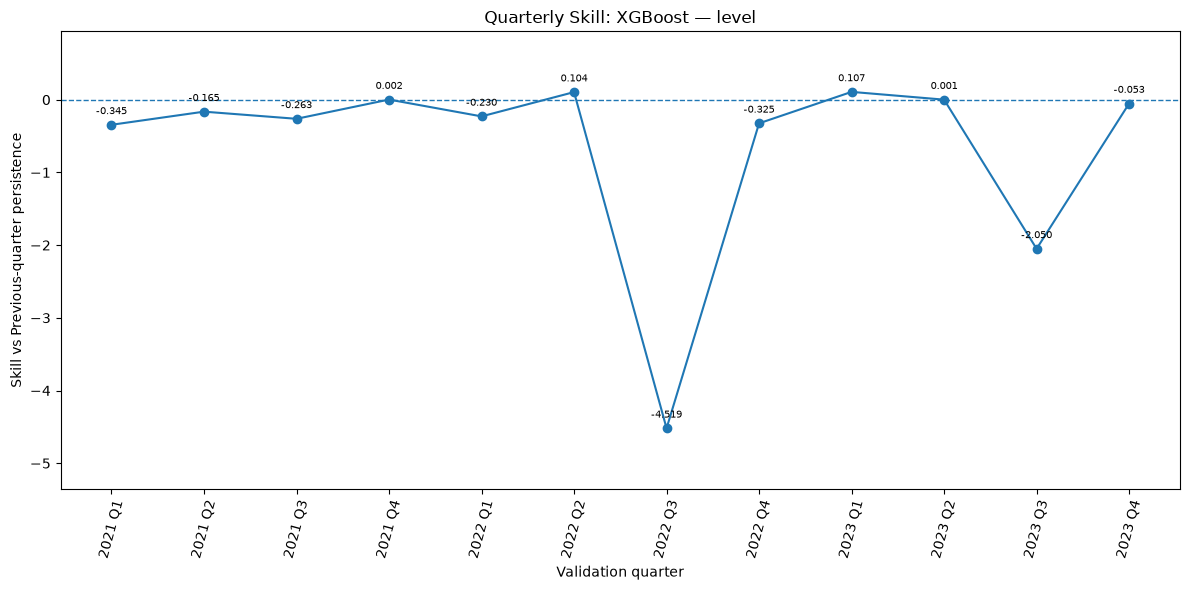

### Generated weekly verdicts

XGBoost — level is the machine-learning specification carried forward to tuning because it achieved the lowest mean rolling-origin MAE among the ML candidates at 2,991.4 encounters, compared with 2,992.7 for Random Forest — level. This selection identifies the strongest ML candidate under the common validation design; it does not imply that ML beat persistence overall.

XGBoost — level had mean rolling MAE 2,991.4, compared with 2,419.0 for Previous-quarter persistence. It beat persistence in 4 of 12 quarters: 2021 Q4 (0.002 skill), 2022 Q2 (0.104 skill), 2023 Q1 (0.107 skill), 2023 Q2 (0.001 skill). Therefore, Previous-quarter persistence remains the stronger overall forecasting method when its mean MAE is lower.

In [16]:
pre_holdout = model_ready.loc[
    model_ready["year"] < HOLDOUT_YEAR
].copy()

all_pre_holdout_periods = sorted(
    pre_holdout["period_index"].unique()
)
validation_periods = all_pre_holdout_periods[
    MIN_TRAIN_QUARTERS:
]

if not validation_periods:
    raise ValueError("There are no rolling validation quarters.")

rolling_metric_rows = []
rolling_prediction_rows = []
selection_rows = []

for validation_period in validation_periods:
    fold_train = pre_holdout.loc[
        pre_holdout["period_index"] < validation_period
    ].copy()

    fold_test = pre_holdout.loc[
        pre_holdout["period_index"] == validation_period
    ].copy()

    actual = fold_test[TARGET].to_numpy()
    baseline_predictions = {
        "Previous-quarter persistence": fold_test["target_lag1"].to_numpy(),
        "Seasonal persistence": fold_test["target_lag4"].to_numpy(),
    }

    for model_name, prediction in baseline_predictions.items():
        rolling_metric_rows.append({
            "validation_period": validation_period,
            "year": int(fold_test["year"].iloc[0]),
            "quarter": fold_test["quarter"].iloc[0],
            "model": model_name,
            **regression_metrics(actual, prediction),
        })

        for row_index, predicted_value in zip(fold_test.index, prediction):
            rolling_prediction_rows.append({
                "validation_period": validation_period,
                "year": int(fold_test.loc[row_index, "year"]),
                "quarter": fold_test.loc[row_index, "quarter"],
                "fips": fold_test.loc[row_index, "fips"],
                "county_name": fold_test.loc[row_index, "county_name"],
                "region": fold_test.loc[row_index, "region"],
                "model": model_name,
                "actual": float(fold_test.loc[row_index, TARGET]),
                "prediction": float(predicted_value),
            })

    for model_name, spec in CANDIDATE_SPECS.items():
        fold_features, _, _ = select_features(
            fold_train,
            spec["target_mode"],
        )

        fitted = fit_predict(
            fold_train,
            fold_test,
            spec,
            fold_features,
        )
        prediction = fitted["prediction"]

        rolling_metric_rows.append({
            "validation_period": validation_period,
            "year": int(fold_test["year"].iloc[0]),
            "quarter": fold_test["quarter"].iloc[0],
            "model": model_name,
            **regression_metrics(actual, prediction),
        })

        for feature in fold_features:
            selection_rows.append({
                "validation_period": validation_period,
                "model": model_name,
                "feature": feature,
            })

        for row_index, predicted_value in zip(fold_test.index, prediction):
            rolling_prediction_rows.append({
                "validation_period": validation_period,
                "year": int(fold_test.loc[row_index, "year"]),
                "quarter": fold_test.loc[row_index, "quarter"],
                "fips": fold_test.loc[row_index, "fips"],
                "county_name": fold_test.loc[row_index, "county_name"],
                "region": fold_test.loc[row_index, "region"],
                "model": model_name,
                "actual": float(fold_test.loc[row_index, TARGET]),
                "prediction": float(predicted_value),
            })

rolling_results = pd.DataFrame(rolling_metric_rows)
rolling_predictions = pd.DataFrame(rolling_prediction_rows)
rolling_predictions["residual"] = (
    rolling_predictions["actual"]
    - rolling_predictions["prediction"]
)
rolling_predictions["absolute_error"] = (
    rolling_predictions["residual"].abs()
)

benchmark_names = [
    "Previous-quarter persistence",
    "Seasonal persistence",
]

benchmark_summary = (
    rolling_results.loc[
        rolling_results["model"].isin(benchmark_names)
    ]
    .groupby("model", as_index=False)["MAE"]
    .mean()
    .sort_values("MAE")
)

STRONGEST_BENCHMARK = benchmark_summary.iloc[0]["model"]

benchmark_by_period = (
    rolling_results.loc[
        rolling_results["model"].eq(STRONGEST_BENCHMARK),
        ["validation_period", "MAE"],
    ]
    .rename(columns={"MAE": "benchmark_MAE"})
)

rolling_results = rolling_results.merge(
    benchmark_by_period,
    on="validation_period",
    how="left",
    validate="many_to_one",
)
rolling_results["skill_vs_strongest_persistence"] = np.where(
    rolling_results["benchmark_MAE"].gt(0),
    1 - rolling_results["MAE"] / rolling_results["benchmark_MAE"],
    np.nan,
)
rolling_results.loc[
    rolling_results["model"].eq(STRONGEST_BENCHMARK),
    "skill_vs_strongest_persistence",
] = 0.0

rolling_summary = (
    rolling_results.groupby("model", as_index=False)
    .agg(
        mean_MAE=("MAE", "mean"),
        median_MAE=("MAE", "median"),
        mean_RMSE=("RMSE", "mean"),
        mean_WAPE=("WAPE", "mean"),
        mean_R2=("R2", "mean"),
        median_R2=("R2", "median"),
        mean_skill=("skill_vs_strongest_persistence", "mean"),
        quarters_beating_benchmark=(
            "skill_vs_strongest_persistence",
            lambda values: int((values > 0).sum()),
        ),
        validation_quarters=("validation_period", "nunique"),
    )
    .sort_values("mean_MAE")
    .reset_index(drop=True)
)

ml_names = list(CANDIDATE_SPECS)
WINNING_ML_NAME = (
    rolling_summary.loc[
        rolling_summary["model"].isin(ml_names)
    ]
    .sort_values("mean_MAE")
    .iloc[0]["model"]
)
WINNING_SPEC = CANDIDATE_SPECS[WINNING_ML_NAME]

display(rolling_summary.round(4))
print("Selected ML candidate:", WINNING_ML_NAME)
print("Strongest persistence benchmark:", STRONGEST_BENCHMARK)

winning_rolling_row = rolling_summary.loc[
    rolling_summary["model"].eq(WINNING_ML_NAME)
].iloc[0]

rolling_verdict = (
    f"{WINNING_ML_NAME} had mean rolling MAE "
    f"{winning_rolling_row['mean_MAE']:,.1f}, mean rolling R² "
    f"{winning_rolling_row['mean_R2']:.3f}, and mean skill "
    f"{winning_rolling_row['mean_skill']:.3f} versus "
    f"{STRONGEST_BENCHMARK}. It beat the benchmark in "
    f"{int(winning_rolling_row['quarters_beating_benchmark'])} of "
    f"{int(winning_rolling_row['validation_quarters'])} validation quarters."
)
print(rolling_verdict)

selection_history = pd.DataFrame(selection_rows)
winning_selection_stability = (
    selection_history.loc[
        selection_history["model"].eq(WINNING_ML_NAME)
    ]
    .groupby("feature", as_index=False)
    .agg(selected_quarters=("validation_period", "nunique"))
)
winning_selection_stability["selection_rate"] = (
    winning_selection_stability["selected_quarters"]
    / len(validation_periods)
)
winning_selection_stability = winning_selection_stability.sort_values(
    ["selection_rate", "feature"],
    ascending=[False, True],
)
print("Feature-selection stability for the selected ML candidate:")
display(winning_selection_stability.head(20).round(3))

region_comparison = (
    rolling_predictions.loc[
        rolling_predictions["model"].isin(
            [STRONGEST_BENCHMARK, WINNING_ML_NAME]
        )
    ]
    .groupby(["model", "region"], as_index=False)
    .agg(
        MAE=("absolute_error", "mean"),
        mean_residual=("residual", "mean"),
        rows=("absolute_error", "size"),
    )
)

print("Pre-holdout error by region:")
display(region_comparison.round(2))

rolling_results.to_csv(
    PROCESSED_DIR / "rolling_origin_results.csv",
    index=False,
)
rolling_predictions.to_csv(
    PROCESSED_DIR / "rolling_origin_predictions.csv",
    index=False,
)
rolling_summary.to_csv(
    PROCESSED_DIR / "rolling_origin_summary.csv",
    index=False,
)
winning_selection_stability.to_csv(
    PROCESSED_DIR / "feature_selection_stability.csv",
    index=False,
)
region_comparison.to_csv(
    PROCESSED_DIR / "rolling_error_by_region.csv",
    index=False,
)

fig, ax = plt.subplots(figsize=(10, 6))
plot_table = rolling_summary.sort_values("mean_MAE")
rolling_mae_bars = ax.barh(plot_table["model"], plot_table["mean_MAE"])
add_bar_value_labels(
    ax,
    rolling_mae_bars,
    formatter=lambda value: format_decimal(value, 1),
    horizontal=True,
)
ax.invert_yaxis()
ax.set_title("Pre-Holdout Rolling Validation MAE")
ax.set_xlabel("Mean MAE across validation quarters")
ax.set_ylabel("Method")
ax.set_xlim(right=plot_table["mean_MAE"].max() * 1.18)
fig.tight_layout()
fig.savefig(
    IMAGE_DIR / "rolling_validation_mae.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

winning_skill = rolling_results.loc[
    rolling_results["model"].eq(WINNING_ML_NAME)
].sort_values("validation_period")

winning_skill["period_label"] = (
    winning_skill["year"].astype(str)
    + " "
    + winning_skill["quarter"].astype(str)
)

# Required quarterly adaptation of the professor's
# rolling-origin skill-by-year deliverable.
skill_by_quarter_table = winning_skill[
    [
        "year",
        "quarter",
        "MAE",
        "benchmark_MAE",
        "RMSE",
        "WAPE",
        "R2",
        "skill_vs_strongest_persistence",
    ]
].copy()

skill_by_quarter_table = skill_by_quarter_table.rename(
    columns={
        "MAE": "model_MAE",
        "benchmark_MAE": "persistence_MAE",
        "R2": "model_R2",
        "skill_vs_strongest_persistence": "skill",
    }
)

skill_by_quarter_table["WAPE_percent"] = (
    skill_by_quarter_table["WAPE"] * 100
)
skill_by_quarter_table = skill_by_quarter_table[
    [
        "year",
        "quarter",
        "model_MAE",
        "persistence_MAE",
        "RMSE",
        "WAPE_percent",
        "model_R2",
        "skill",
    ]
]

print(f"Rolling-origin results for {WINNING_ML_NAME}:")
display(
    skill_by_quarter_table.round(
        {
            "model_MAE": 1,
            "persistence_MAE": 1,
            "RMSE": 1,
            "WAPE_percent": 2,
            "model_R2": 4,
            "skill": 4,
        }
    )
)

skill_by_quarter_table.to_csv(
    PROCESSED_DIR / "winning_model_skill_by_quarter.csv",
    index=False,
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(
    winning_skill["period_label"],
    winning_skill["skill_vs_strongest_persistence"],
    marker="o",
)
ax.axhline(0, linestyle="--", linewidth=1)
add_line_value_labels(
    ax,
    winning_skill["period_label"],
    winning_skill["skill_vs_strongest_persistence"],
    formatter=lambda value: format_decimal(value, 3),
    fontsize=7,
    offset_points=6,
)
ax.tick_params(axis="x", rotation=75)
ax.set_title(f"Quarterly Skill: {WINNING_ML_NAME}")
ax.set_xlabel("Validation quarter")
ax.set_ylabel(f"Skill vs {STRONGEST_BENCHMARK}")
ax.margins(y=0.18)
fig.tight_layout()
fig.savefig(
    IMAGE_DIR / "rolling_skill_by_quarter.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

# Generate the two required narrative paragraphs directly from the
# rolling-origin results so names, errors, skill, and quarters stay synchronized.
ml_ranking = (
    rolling_summary.loc[rolling_summary["model"].isin(CANDIDATE_SPECS)]
    .sort_values("mean_MAE")
    .reset_index(drop=True)
)
winner_row = ml_ranking.iloc[0]
runner_up_row = ml_ranking.iloc[1] if len(ml_ranking) > 1 else None
benchmark_row_rolling = rolling_summary.loc[
    rolling_summary["model"].eq(STRONGEST_BENCHMARK)
].iloc[0]

runner_up_clause = ""
if runner_up_row is not None:
    runner_up_clause = (
        f", compared with {runner_up_row['mean_MAE']:,.1f} for "
        f"{runner_up_row['model']}"
    )

carry_forward_paragraph = (
    f"{winner_row['model']} is the machine-learning specification carried "
    f"forward to tuning because it achieved the lowest mean rolling-origin "
    f"MAE among the ML candidates at {winner_row['mean_MAE']:,.1f} encounters"
    f"{runner_up_clause}. This selection identifies the strongest ML candidate "
    f"under the common validation design; it does not imply that ML beat "
    f"persistence overall."
)

winning_quarters = rolling_results.loc[
    rolling_results["model"].eq(WINNING_ML_NAME)
    & rolling_results["skill_vs_strongest_persistence"].gt(0),
    ["year", "quarter", "skill_vs_strongest_persistence"],
].sort_values(["year", "quarter"])

if winning_quarters.empty:
    quarter_clause = "It did not beat persistence in any validation quarter."
else:
    quarter_labels = [
        f"{int(row.year)} {row.quarter} ({row.skill_vs_strongest_persistence:.3f} skill)"
        for row in winning_quarters.itertuples()
    ]
    quarter_clause = (
        f"It beat persistence in {len(winning_quarters)} of "
        f"{int(winner_row['validation_quarters'])} quarters: "
        + ", ".join(quarter_labels)
        + "."
    )

rolling_value_paragraph = (
    f"{WINNING_ML_NAME} had mean rolling MAE "
    f"{winner_row['mean_MAE']:,.1f}, compared with "
    f"{benchmark_row_rolling['mean_MAE']:,.1f} for "
    f"{STRONGEST_BENCHMARK}. {quarter_clause} "
    f"Therefore, {STRONGEST_BENCHMARK} remains the stronger overall "
    f"forecasting method when its mean MAE is lower."
)

display(
    Markdown(
        "### Generated weekly verdicts\n\n"
        + carry_forward_paragraph
        + "\n\n"
        + rolling_value_paragraph
    )
)


### Rolling-validation chart interpretation

The MAE chart ranks methods by average out-of-time error; shorter bars are better. Previous-quarter persistence is the strongest overall method. XGBoost — level has the lowest mean rolling-origin MAE among the machine-learning candidates at 2,989.1 encounters, narrowly ahead of Random Forest — level at 2,992.7. Their average performance is therefore practically similar. The level models outperform their corresponding change-from-seasonal-persistence versions, indicating that the available predictors explain encounter levels more reliably than year-over-year deviations.

In the skill chart, zero means equal performance to the strongest persistence benchmark, positive values mean improvement, and negative values mean worse performance. XGBoost — level beats persistence in only 2 of 12 validation quarters. Extremely negative skill can occur when persistence has unusually low error in a quarter, so skill should always be interpreted together with the underlying MAE.


### When the model adds value over persistence

The two verdict paragraphs printed above are generated directly from the rolling-origin tables. They report the selected ML specification, its mean MAE, the strongest persistence benchmark, and the exact quarters in which ML achieved positive skill.


### Progress checkpoint

- [x] **Phase 1: Configuration** — quarterly target, geography, lags, external-predictor timing, and holdout rules defined
- [x] **Task 1: Data Collection** — SPARCS, county geography, ACS, and weather sources acquired and documented
- [x] **Task 2: Cleaning & Preprocessing** — county-quarter aggregation, type conversion, source alignment, key checks, and coverage review
- [x] **Task 3: EDA & Visualization** — statewide context, seasonality, county demand, demographic/weather relationships, correlation, and VIF
- [x] **Task 4: Feature Engineering & Selection** — exact quarterly lags, leakage exclusions, and target-specific training-only selection
- [x] **Week of July 14 — Task 5: Model Development** — quarterly persistence baselines, compact candidate set, and a paragraph naming the ML family carried forward
- [x] **Week of July 21 — Task 6: Validation** — expanding-window validation by complete quarter, skill versus persistence, and a paragraph explaining when the ML model adds value
- [ ] **Week of July 28 — Tasks 7–10** — tuning, final holdout, SHAP, serialization, inference validation, model card, and results summary


### summary

1. Retained the county-quarter target and quarterly lag logic (`target_lag1` and `target_lag4`).
2. Preserved two-year-lag ACS and same-quarter previous-year weather alignment.
3. Organized the notebook into explicit phases and Tasks 1–6 through the July 21 checkpoint.
4. Kept the compact candidate set and both level and change-from-seasonal-persistence formulations.
5. Used complete-quarter rolling-origin folds rather than row-based time splits.
6. Refit feature selection, scaling, and model estimation inside every validation fold.
7. Compared candidates with the strongest quarterly persistence benchmark and summarized stability across time and geography.
8. Identified the ML family and target formulation eligible to continue into the July 28 optimization and finalization phase.


# Phase 6 — Model Optimization, Final Evaluation, and Delivery

## Tuning, Artifact, and Final Reporting

### Task 7 — Feature pruning and time-aware tuning

Only the selected machine-learning candidate—its family and its target formulation—is tuned. A short, understandable parameter list is evaluated on the last eight pre-holdout validation quarters.

Feature pruning remains leakage-safe:

- fold-constant predictors are removed;
- feature selection is refitted inside each tuning fold;
- feature counts of 10, 15, and 20 are explicitly compared;
- redundant or weak predictors are not carried into the final artifact merely because they were available;
- every tuning configuration is compared with both the untuned candidate and the strongest persistence benchmark on the same quarters;
- the final holdout remains locked and unused during pruning and tuning.

This task locks the model family, target formulation, hyperparameters, and feature-selection count before final evaluation.


In [17]:
TUNING_OPTIONS = {
    "Ridge": [
        {"alpha": 1.0},
        {"alpha": 10.0},
        {"alpha": 50.0},
    ],
    "Random Forest": [
        {
            "n_estimators": 300,
            "min_samples_leaf": 3,
            "max_features": "sqrt",
        },
        {
            "n_estimators": 400,
            "min_samples_leaf": 5,
            "max_features": 0.7,
        },
        {
            "n_estimators": 500,
            "min_samples_leaf": 8,
            "max_features": 1.0,
        },
    ],
    "XGBoost": [
        {
            "n_estimators": 300,
            "max_depth": 3,
            "learning_rate": 0.05,
            "subsample": 0.9,
            "colsample_bytree": 0.9,
            "reg_lambda": 1.0,
        },
        {
            "n_estimators": 450,
            "max_depth": 4,
            "learning_rate": 0.05,
            "subsample": 0.9,
            "colsample_bytree": 0.9,
            "reg_lambda": 1.0,
        },
        {
            "n_estimators": 350,
            "max_depth": 5,
            "learning_rate": 0.03,
            "subsample": 0.85,
            "colsample_bytree": 0.9,
            "reg_lambda": 5.0,
        },
    ],
}

# The last eight pre-holdout quarters are used consistently for tuning.
tuning_periods = validation_periods[-8:]

benchmark_tuning_mae = float(
    rolling_results.loc[
        rolling_results["model"].eq(STRONGEST_BENCHMARK)
        & rolling_results["validation_period"].isin(tuning_periods),
        "MAE",
    ].mean()
)

untuned_tuning_mae = float(
    rolling_results.loc[
        rolling_results["model"].eq(WINNING_ML_NAME)
        & rolling_results["validation_period"].isin(tuning_periods),
        "MAE",
    ].mean()
)

untuned_tuning_skill = (
    1 - untuned_tuning_mae / benchmark_tuning_mae
    if benchmark_tuning_mae > 0
    else np.nan
)

tuning_rows = []

for feature_count in FEATURE_SELECTION_K_OPTIONS:
    for params in TUNING_OPTIONS[WINNING_SPEC["family"]]:
        fold_maes = []

        for validation_period in tuning_periods:
            fold_train = pre_holdout.loc[
                pre_holdout["period_index"] < validation_period
            ].copy()
            fold_test = pre_holdout.loc[
                pre_holdout["period_index"] == validation_period
            ].copy()

            fold_features, _, _ = select_features(
                fold_train,
                WINNING_SPEC["target_mode"],
                k=feature_count,
            )

            estimator = clone(
                WINNING_SPEC["estimator"]
            ).set_params(**params)

            prediction = fit_predict(
                fold_train,
                fold_test,
                WINNING_SPEC,
                fold_features,
                estimator=estimator,
            )["prediction"]

            fold_maes.append(
                mean_absolute_error(
                    fold_test[TARGET],
                    prediction,
                )
            )

        mean_validation_mae = float(np.mean(fold_maes))
        tuning_rows.append({
            "feature_count": int(feature_count),
            "params": params,
            "mean_validation_MAE": mean_validation_mae,
            "mean_persistence_MAE": benchmark_tuning_mae,
            "skill_vs_persistence": (
                1 - mean_validation_mae / benchmark_tuning_mae
                if benchmark_tuning_mae > 0
                else np.nan
            ),
            "MAE_improvement_vs_untuned": (
                untuned_tuning_mae - mean_validation_mae
            ),
        })

tuning_results = (
    pd.DataFrame(tuning_rows)
    .sort_values(
        ["mean_validation_MAE", "feature_count"],
        ascending=[True, True],
    )
    .reset_index(drop=True)
)

BEST_PARAMS = dict(tuning_results.iloc[0]["params"])
BEST_FEATURE_COUNT = int(tuning_results.iloc[0]["feature_count"])
best_tuned_mae = float(tuning_results.iloc[0]["mean_validation_MAE"])
best_tuned_skill = float(tuning_results.iloc[0]["skill_vs_persistence"])

display(tuning_results.round(4))
print(
    "Strongest persistence mean MAE on tuning quarters:",
    round(benchmark_tuning_mae, 2),
)
print(
    "Untuned mean MAE on the same tuning quarters:",
    round(untuned_tuning_mae, 2),
)
print(
    "Untuned skill vs persistence:",
    round(untuned_tuning_skill, 3),
)
print(
    "Best tuned mean MAE on those quarters:",
    round(best_tuned_mae, 2),
)
print(
    "Best tuned skill vs persistence:",
    round(best_tuned_skill, 3),
)
print(
    "MAE reduction from untuned to tuned:",
    round(untuned_tuning_mae - best_tuned_mae, 2),
)
print("Best feature count:", BEST_FEATURE_COUNT)
print("Best parameters:", BEST_PARAMS)

tuning_results.assign(
    params=tuning_results["params"].astype(str)
).to_csv(
    PROCESSED_DIR / "tuning_results.csv",
    index=False,
)


,feature_count,params,mean_validation_MAE,mean_persistence_MAE,skill_vs_persistence,MAE_improvement_vs_untuned
0,20,"{'n_estimators': 350, 'max_depth': 5, 'learnin...",2540.5878,2269.4182,-0.1195,316.8752
1,15,"{'n_estimators': 350, 'max_depth': 5, 'learnin...",2657.6830,2269.4182,-0.1711,199.7800
2,20,"{'n_estimators': 450, 'max_depth': 4, 'learnin...",2670.7920,2269.4182,-0.1769,186.6710
3,15,"{'n_estimators': 300, 'max_depth': 3, 'learnin...",2787.4816,2269.4182,-0.2283,69.9814
4,20,"{'n_estimators': 300, 'max_depth': 3, 'learnin...",2806.7454,2269.4182,-0.2368,50.7175
5,15,"{'n_estimators': 450, 'max_depth': 4, 'learnin...",2881.2278,2269.4182,-0.2696,-23.7648
6,10,"{'n_estimators': 300, 'max_depth': 3, 'learnin...",2969.0924,2269.4182,-0.3083,-111.6294
7,10,"{'n_estimators': 350, 'max_depth': 5, 'learnin...",3030.7188,2269.4182,-0.3355,-173.2558
8,10,"{'n_estimators': 450, 'max_depth': 4, 'learnin...",3043.7722,2269.4182,-0.3412,-186.3092


Strongest persistence mean MAE on tuning quarters: 2269.42
Untuned mean MAE on the same tuning quarters: 2857.46
Untuned skill vs persistence: -0.259
Best tuned mean MAE on those quarters: 2540.59
Best tuned skill vs persistence: -0.119
MAE reduction from untuned to tuned: 316.88
Best feature count: 20
Best parameters: {'n_estimators': 350, 'max_depth': 5, 'learning_rate': 0.03, 'subsample': 0.85, 'colsample_bytree': 0.9, 'reg_lambda': 5.0}


### Task 8 — Locked final holdout evaluation

The locked final holdout is evaluated only after the ML family, target formulation, feature-selection procedure, feature count, and tuning choices are fixed.

The evaluation compares the selected ML model with both quarterly persistence benchmarks and reports out-of-time MAE, RMSE, WAPE, level R², change-based R² relative to both previous-quarter and seasonal persistence, and skill versus the strongest persistence benchmark. Error is also reviewed by quarter, region, and county.


,model,MAE,RMSE,WAPE,R2,R2_change_from_previous_quarter,R2_change_from_seasonal_persistence,skill_vs_strongest_persistence
0,Previous-quarter persistence,1252.6462,3421.1299,0.0336,0.9970,-0.0088,0.7889,0.0000
1,Tuned XGBoost — level,2144.0415,5204.8825,0.0575,0.9930,-1.3350,0.5115,-0.7116
2,Seasonal persistence,2840.8349,7723.1242,0.0761,0.9846,-4.1411,-0.0756,-1.2679


Holdout comparison by quarter:


,method,quarter,rows,MAE,mean_residual
0,Previous-quarter persistence,Q1,53,2569.21,352.72
1,Previous-quarter persistence,Q2,53,699.23,383.75
2,Previous-quarter persistence,Q3,53,715.96,350.00
3,Previous-quarter persistence,Q4,53,1026.19,191.81
4,Tuned XGBoost — level,Q1,53,2812.20,1636.30
5,Tuned XGBoost — level,Q2,53,1566.24,589.05
6,Tuned XGBoost — level,Q3,53,2082.62,1201.89
7,Tuned XGBoost — level,Q4,53,2115.11,1484.00


Holdout comparison by region:


,method,region,rows,MAE,mean_residual
0,Previous-quarter persistence,downstate_non_nyc,16,3885.31,1092.81
1,Previous-quarter persistence,nyc,20,4925.55,2202.25
2,Previous-quarter persistence,upstate,176,595.94,35.34
3,Tuned XGBoost — level,downstate_non_nyc,16,6169.28,821.13
4,Tuned XGBoost — level,nyc,20,9829.17,9606.08
5,Tuned XGBoost — level,upstate,176,904.80,312.71


Counties with the largest ML holdout MAE:


,fips,county_name,quarters,MAE,mean_residual
36,36081,Queens County,4,25067.44,25067.44
20,36047,Kings County,4,14095.92,14095.92
45,36103,Suffolk County,4,12540.65,12540.65
26,36059,Nassau County,4,6322.28,-4284.18
14,36029,Erie County,4,5476.62,5087.72
51,36119,Westchester County,4,5217.10,-5217.10
27,36061,New York County,4,5192.89,5192.89
29,36065,Oneida County,4,4196.01,4196.01
2,36005,Bronx County,4,4167.18,3051.71
0,36001,Albany County,4,3845.34,3845.34


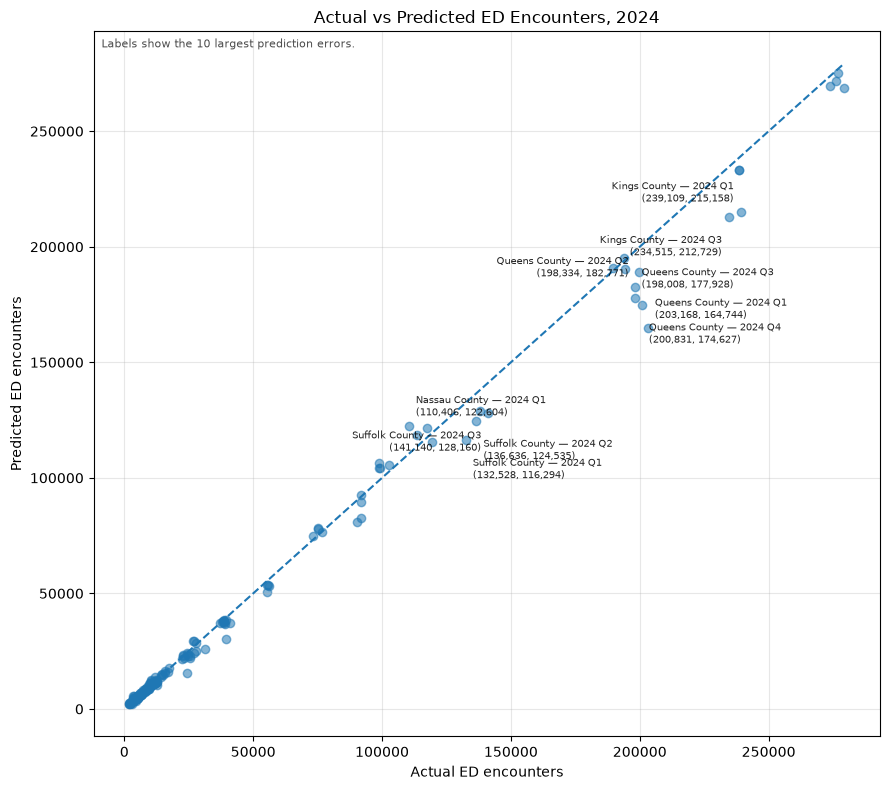

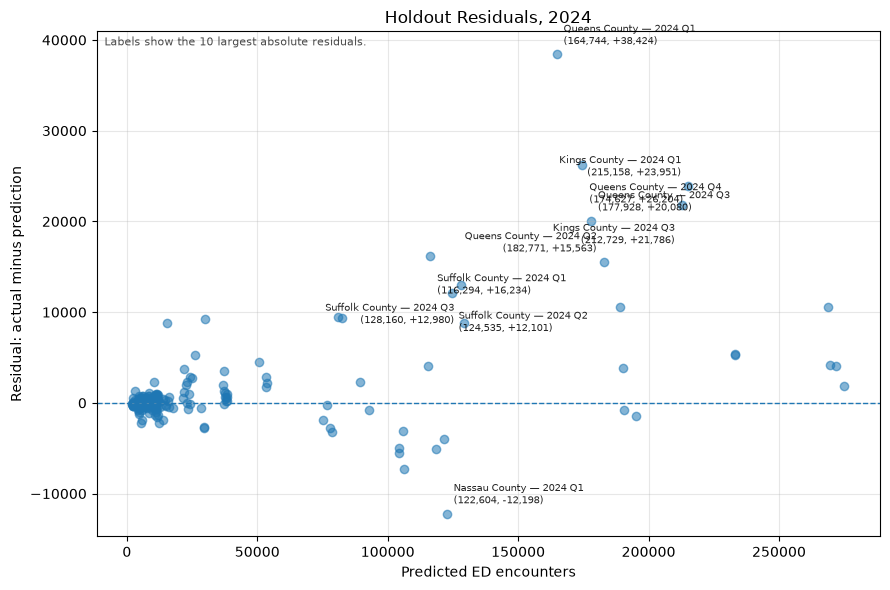

Final selected features: ['target_lag1', 'target_lag2', 'target_lag3', 'target_lag4', 'acs_lag2_population_100k', 'facility_count_lag1', 'is_nyc', 'lat', 'acs_lag2_pct_65plus', 'acs_lag2_pct_under5', 'weather_lag4_wet_days', 'acs_lag2_median_income', 'lon', 'is_downstate_non_nyc', 'acs_lag2_poverty_rate', 'weather_lag4_snowfall_total', 'weather_lag4_hot_days', 'weather_lag4_tavg_mean', 'weather_lag4_freeze_days', 'weather_lag4_precip_total']


In [18]:
final_features, _, final_feature_report = select_features(
    holdout_train,
    WINNING_SPEC["target_mode"],
    k=BEST_FEATURE_COUNT,
)

final_estimator = clone(
    WINNING_SPEC["estimator"]
).set_params(**BEST_PARAMS)

final_fit = fit_predict(
    holdout_train,
    holdout_test,
    WINNING_SPEC,
    final_features,
    estimator=final_estimator,
)

ml_prediction = final_fit["prediction"]
actual = holdout_test[TARGET].to_numpy()
lag1_prediction = holdout_test["target_lag1"].to_numpy()
lag4_prediction = holdout_test["target_lag4"].to_numpy()

prediction_map = {
    "Previous-quarter persistence": lag1_prediction,
    "Seasonal persistence": lag4_prediction,
    f"Tuned {WINNING_ML_NAME}": ml_prediction,
}

benchmark_prediction = (
    lag1_prediction
    if STRONGEST_BENCHMARK == "Previous-quarter persistence"
    else lag4_prediction
)

comparison_rows = []
for model_name, prediction in prediction_map.items():
    comparison_rows.append({
        "model": model_name,
        **regression_metrics(actual, prediction),
        "R2_change_from_previous_quarter": change_r2(
            actual,
            prediction,
            lag1_prediction,
        ),
        "R2_change_from_seasonal_persistence": change_r2(
            actual,
            prediction,
            lag4_prediction,
        ),
        "skill_vs_strongest_persistence": (
            0.0
            if model_name == STRONGEST_BENCHMARK
            else skill_vs(
                actual,
                prediction,
                benchmark_prediction,
            )
        ),
    })

final_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(final_comparison.round(4))
final_comparison.to_csv(
    PROCESSED_DIR / "final_holdout_comparison.csv",
    index=False,
)
final_feature_report.to_csv(
    PROCESSED_DIR / "final_feature_selection.csv",
    index=False,
)

holdout_predictions = holdout_test[
    [
        "fips",
        "county_name",
        "year",
        "quarter",
        "quarter_num",
        "region",
        TARGET,
    ]
].copy()

holdout_predictions["previous_quarter_persistence"] = lag1_prediction
holdout_predictions["seasonal_persistence"] = lag4_prediction
holdout_predictions["ml_prediction"] = ml_prediction
holdout_predictions["ml_residual"] = (
    holdout_predictions[TARGET]
    - holdout_predictions["ml_prediction"]
)
holdout_predictions["ml_absolute_error"] = (
    holdout_predictions["ml_residual"].abs()
)
holdout_predictions["benchmark_prediction"] = benchmark_prediction
holdout_predictions["benchmark_residual"] = (
    holdout_predictions[TARGET]
    - holdout_predictions["benchmark_prediction"]
)
holdout_predictions["benchmark_absolute_error"] = (
    holdout_predictions["benchmark_residual"].abs()
)
holdout_predictions.to_csv(
    PROCESSED_DIR / "holdout_predictions.csv",
    index=False,
)

holdout_method_predictions = pd.concat(
    [
        holdout_predictions.assign(
            method=f"Tuned {WINNING_ML_NAME}",
            prediction=holdout_predictions["ml_prediction"],
            residual=holdout_predictions["ml_residual"],
            absolute_error=holdout_predictions["ml_absolute_error"],
        ),
        holdout_predictions.assign(
            method=STRONGEST_BENCHMARK,
            prediction=holdout_predictions["benchmark_prediction"],
            residual=holdout_predictions["benchmark_residual"],
            absolute_error=holdout_predictions["benchmark_absolute_error"],
        ),
    ],
    ignore_index=True,
)

error_by_quarter = (
    holdout_method_predictions.groupby(
        ["method", "quarter"],
        as_index=False,
    )
    .agg(
        rows=(TARGET, "size"),
        MAE=("absolute_error", "mean"),
        mean_residual=("residual", "mean"),
    )
)

error_by_region = (
    holdout_method_predictions.groupby(
        ["method", "region"],
        as_index=False,
    )
    .agg(
        rows=(TARGET, "size"),
        MAE=("absolute_error", "mean"),
        mean_residual=("residual", "mean"),
    )
)

error_by_county = (
    holdout_predictions.groupby(
        ["fips", "county_name"],
        as_index=False,
    )
    .agg(
        quarters=(TARGET, "size"),
        MAE=("ml_absolute_error", "mean"),
        mean_residual=("ml_residual", "mean"),
    )
    .sort_values("MAE", ascending=False)
)

print("Holdout comparison by quarter:")
display(error_by_quarter.round(2))

print("Holdout comparison by region:")
display(error_by_region.round(2))

print("Counties with the largest ML holdout MAE:")
display(error_by_county.head(10).round(2))

error_by_quarter.to_csv(
    PROCESSED_DIR / "holdout_error_by_quarter.csv",
    index=False,
)
error_by_region.to_csv(
    PROCESSED_DIR / "holdout_error_by_region.csv",
    index=False,
)
error_by_county.to_csv(
    PROCESSED_DIR / "holdout_error_by_county.csv",
    index=False,
)

holdout_plot_data = holdout_predictions.assign(
    actual=holdout_predictions[TARGET],
    predicted=holdout_predictions["ml_prediction"],
    absolute_error=holdout_predictions["ml_absolute_error"],
)
holdout_plot_data["observation_label"] = (
    holdout_plot_data["county_name"].astype(str)
    + " — "
    + holdout_plot_data["year"].astype(int).astype(str)
    + " "
    + holdout_plot_data["quarter"].astype(str)
)

fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(
    holdout_plot_data["actual"],
    holdout_plot_data["predicted"],
    alpha=0.55,
)
lower = min(
    holdout_plot_data["actual"].min(),
    holdout_plot_data["predicted"].min(),
)
upper = max(
    holdout_plot_data["actual"].max(),
    holdout_plot_data["predicted"].max(),
)
ax.plot([lower, upper], [lower, upper], linestyle="--")
add_selected_scatter_labels(
    ax,
    holdout_plot_data,
    x_column="actual",
    y_column="predicted",
    label_column="observation_label",
    score_column="absolute_error",
    n_labels=10,
    x_formatter=format_count,
    y_formatter=format_count,
    note="Labels show the 10 largest prediction errors.",
)
ax.set_title(f"Actual vs Predicted ED Encounters, {HOLDOUT_YEAR}")
ax.set_xlabel("Actual ED encounters")
ax.set_ylabel("Predicted ED encounters")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(
    IMAGE_DIR / "actual_vs_predicted.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    holdout_plot_data["predicted"],
    holdout_predictions["ml_residual"],
    alpha=0.55,
)
ax.axhline(0, linestyle="--", linewidth=1)

residual_plot_data = holdout_plot_data.assign(
    residual=holdout_predictions["ml_residual"],
)
add_selected_scatter_labels(
    ax,
    residual_plot_data,
    x_column="predicted",
    y_column="residual",
    label_column="observation_label",
    score_column="absolute_error",
    n_labels=10,
    x_formatter=format_count,
    y_formatter=lambda value: f"{value:+,.0f}",
    note="Labels show the 10 largest absolute residuals.",
)
ax.set_title(f"Holdout Residuals, {HOLDOUT_YEAR}")
ax.set_xlabel("Predicted ED encounters")
ax.set_ylabel("Residual: actual minus prediction")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(
    IMAGE_DIR / "holdout_residuals.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print("Final selected features:", final_features)


### Holdout diagnostic interpretation

In the actual-versus-predicted chart, the dashed 45-degree line represents perfect predictions. Points below the line are underpredictions and points above it are overpredictions. The labeled points are separate county-quarter observations, so the same county can appear several times.

Residuals are defined as `actual - prediction`. Positive residuals therefore mean underprediction, while negative residuals mean overprediction. Residuals are defined as actual - prediction. Positive residuals indicate underprediction, while negative residuals indicate overprediction. The largest absolute errors are concentrated in high-volume counties, particularly New York City and several nearby counties. New York City is underpredicted on average, while downstate non-NYC counties include both substantial underpredictions and overpredictions. This pattern is consistent with regression toward the mean in the selected tree-based XGBoost model, which generally does not extrapolate large new demand levels beyond patterns represented in training.


### Task 9 — Model interpretation and error diagnosis

SHAP describes the selected machine-learning model, not the persistence benchmark.

- For a level model, SHAP explains the predicted encounter level.
- For a change model, SHAP explains the predicted deviation from `target_lag4`; the seasonal persistence value is added afterward to reconstruct the level.
- Global importance and beeswarm plots summarize overall feature influence.
- A local waterfall explains the largest holdout error so interpretation is connected to model risk rather than only average behavior.

Tree models use `tree_path_dependent` SHAP without a background dataset, which avoids the categorical-split compatibility error seen with XGBoost.

The SHAP importance bar chart reports `mean(|SHAP value|)`: average impact magnitude in model-output units, not a positive causal effect. In the beeswarm, horizontal position gives the direction and size of the contribution, while color represents the observed feature value. Because demand lags and population are strongly correlated, attribution can be shared among them and their exact ranking should not be interpreted as independent causal importance.

In the local waterfall, red features push the prediction above the model's average output and blue features push it below. The waterfall explains why the model produced its prediction; it does not explain the actual outcome or prove causality.


,feature,mean_abs_shap
0,target_lag1,19281.439453
4,acs_lag2_population_100k,11095.462891
1,target_lag2,3707.728027
2,target_lag3,2395.709961
10,weather_lag4_wet_days,1382.452026
6,is_nyc,744.114990
3,target_lag4,504.208008
17,weather_lag4_tavg_mean,471.403015
14,acs_lag2_poverty_rate,452.153992
5,facility_count_lag1,333.269012


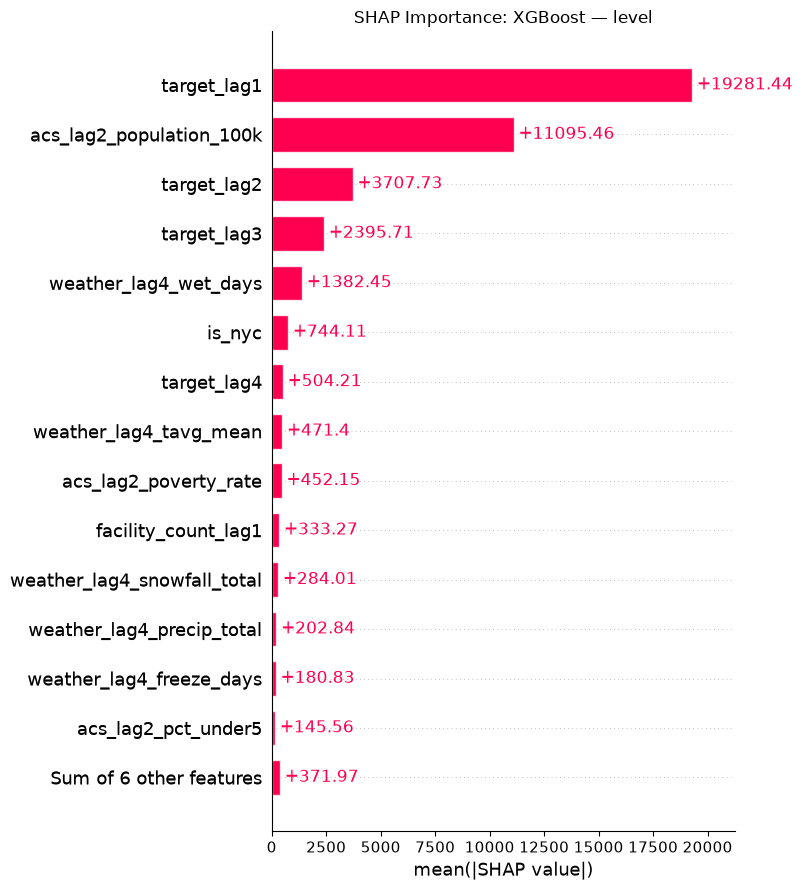

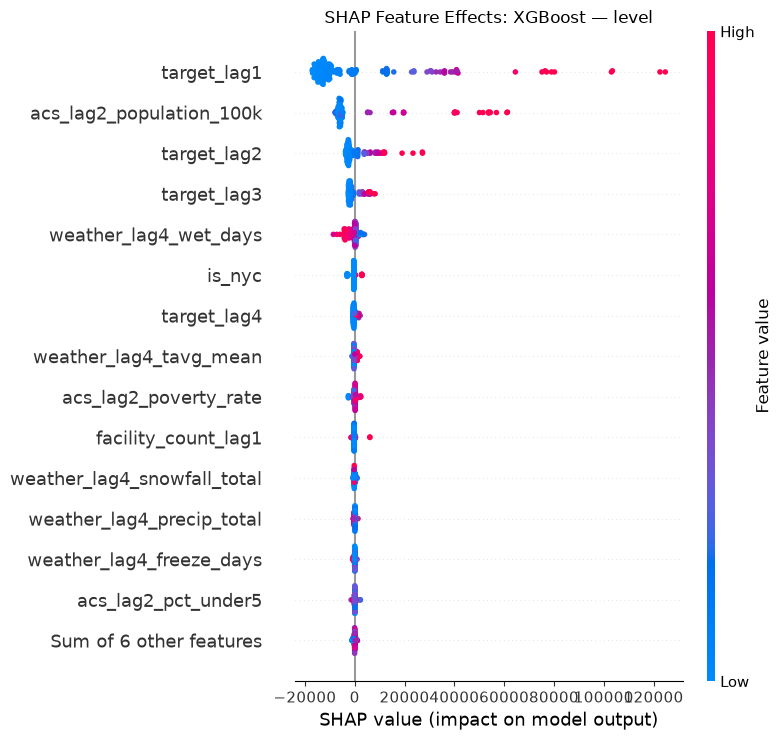

Largest holdout error:


,county_name,year,quarter,total_ed_encounters,ml_prediction,ml_residual
1360,Queens County,2024,Q1,203168,164744.234375,38423.765625


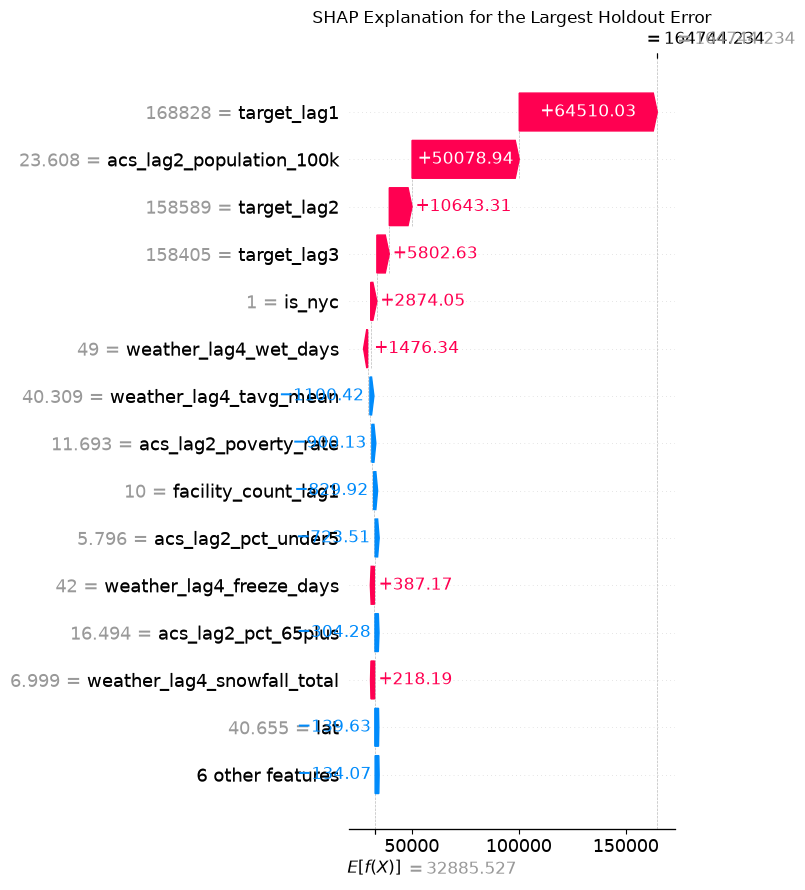

In [19]:
X_train_shap = holdout_train[final_features].astype(float)
X_test_shap = holdout_test[final_features].astype(float)

if final_fit["scaler"] is not None:
    X_train_shap = pd.DataFrame(
        final_fit["scaler"].transform(X_train_shap),
        columns=final_features,
        index=X_train_shap.index,
    )
    X_test_shap = pd.DataFrame(
        final_fit["scaler"].transform(X_test_shap),
        columns=final_features,
        index=X_test_shap.index,
    )

X_explain = X_test_shap.sample(
    min(150, len(X_test_shap)),
    random_state=42,
)

model_for_shap = final_fit["model"]

if WINNING_SPEC["family"] == "Ridge":
    background = X_train_shap.sample(
        min(200, len(X_train_shap)),
        random_state=42,
    )
    explainer = shap.LinearExplainer(
        model_for_shap,
        background,
    )
    shap_values = explainer(X_explain)
else:
    explainer = shap.TreeExplainer(
        model_for_shap,
        feature_perturbation="tree_path_dependent",
        model_output="raw",
    )
    shap_values = explainer(
        X_explain,
        check_additivity=False,
    )

shap_importance = pd.DataFrame({
    "feature": final_features,
    "mean_abs_shap": np.abs(shap_values.values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

display(shap_importance.head(15).round(3))
shap_importance.to_csv(
    PROCESSED_DIR / "shap_feature_importance.csv",
    index=False,
)

shap.plots.bar(
    shap_values,
    max_display=15,
    show=False,
)
shap_bar_ax = plt.gca()
if not shap_bar_ax.texts:
    for patch in shap_bar_ax.patches:
        width = patch.get_width()
        if np.isfinite(width) and width > 0:
            shap_bar_ax.annotate(
                format_decimal(width, 2),
                xy=(width, patch.get_y() + patch.get_height() / 2),
                xytext=(4, 0),
                textcoords="offset points",
                ha="left",
                va="center",
                fontsize=8,
            )
plt.title(f"SHAP Importance: {WINNING_ML_NAME}")
plt.tight_layout()
plt.savefig(
    IMAGE_DIR / "shap_importance.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

shap.plots.beeswarm(
    shap_values,
    max_display=15,
    show=False,
)
plt.title(f"SHAP Feature Effects: {WINNING_ML_NAME}")
plt.tight_layout()
plt.savefig(
    IMAGE_DIR / "shap_beeswarm.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

largest_error_index = holdout_predictions["ml_absolute_error"].idxmax()
X_local = X_test_shap.loc[[largest_error_index]]

if WINNING_SPEC["family"] == "Ridge":
    local_shap_values = explainer(X_local)
else:
    local_shap_values = explainer(
        X_local,
        check_additivity=False,
    )

print("Largest holdout error:")
display(
    holdout_predictions.loc[
        [largest_error_index],
        [
            "county_name",
            "year",
            "quarter",
            TARGET,
            "ml_prediction",
            "ml_residual",
        ],
    ]
)

shap.plots.waterfall(
    local_shap_values[0],
    max_display=15,
    show=False,
)
plt.title("SHAP Explanation for the Largest Holdout Error")
plt.tight_layout()
plt.savefig(
    IMAGE_DIR / "shap_largest_error_waterfall.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


### Task 10 — Inference validation, saved artifact, model card, and final reporting

The saved artifact contains the target definition, selected features, scaler when required, fitted ML model, target formulation, validation choice, final metrics, training and holdout periods, data snapshot date, and recommended operational method.

Three small prediction functions are validated separately:

- the tuned machine-learning path;
- previous-quarter and seasonal persistence;
- the final recommended-method path.

This ensures that the serialized ML model is tested even when persistence remains the operational recommendation.


In [20]:
ml_model_label = f"Tuned {WINNING_ML_NAME}"

ml_row = final_comparison.loc[
    final_comparison["model"].eq(ml_model_label)
].iloc[0]

benchmark_row = final_comparison.loc[
    final_comparison["model"].eq(STRONGEST_BENCHMARK)
].iloc[0]

if ml_row["MAE"] < benchmark_row["MAE"]:
    RECOMMENDED_METHOD = ml_model_label
    recommendation = (
        f"The tuned ML model reduced holdout MAE from "
        f"{benchmark_row['MAE']:,.0f} to {ml_row['MAE']:,.0f}. "
        "Use it as the preferred prototype forecast and monitor "
        "performance after each new quarter."
    )
else:
    RECOMMENDED_METHOD = STRONGEST_BENCHMARK
    recommendation = (
        f"The tuned ML model did not beat {STRONGEST_BENCHMARK} "
        f"on the final holdout. Benchmark MAE was "
        f"{benchmark_row['MAE']:,.0f}; ML MAE was "
        f"{ml_row['MAE']:,.0f}. Use persistence as the primary "
        "prototype forecast and retain ML for comparison and diagnostics."
    )

print("Recommended method:", RECOMMENDED_METHOD)
print(recommendation)


def _validated_numeric_columns(frame, columns, label):
    missing_columns = [column for column in columns if column not in frame.columns]
    if missing_columns:
        raise ValueError(f"Missing required {label} columns: {missing_columns}")

    try:
        numeric = frame.loc[:, columns].apply(pd.to_numeric, errors="raise")
    except (TypeError, ValueError) as exc:
        raise ValueError(
            f"{label.capitalize()} columns must be numeric-compatible."
        ) from exc

    columns_with_missing = numeric.columns[numeric.isna().any()].tolist()
    if columns_with_missing:
        raise ValueError(
            f"Missing values found in {label} columns: {columns_with_missing}"
        )

    if not np.isfinite(numeric.to_numpy(dtype=float)).all():
        raise ValueError(f"Non-finite values found in {label} columns.")

    return numeric


def predict_ml_quarterly_ed(input_frame, model_artifact):
    """Return the saved machine-learning model's level prediction."""
    if not isinstance(input_frame, pd.DataFrame):
        raise TypeError("input_frame must be a pandas DataFrame.")

    features = list(model_artifact["features"])
    X = _validated_numeric_columns(input_frame, features, "model feature")

    scaler = model_artifact["scaler"]
    X_fit = scaler.transform(X) if scaler is not None else X
    component_prediction = model_artifact["model"].predict(X_fit)

    if model_artifact["target_mode"] == "change":
        lag = _validated_numeric_columns(
            input_frame,
            ["target_lag4"],
            "reconstruction lag",
        )
        return lag["target_lag4"].to_numpy() + component_prediction

    return np.asarray(component_prediction)


def predict_persistence(input_frame, method):
    """Return a previous-quarter or seasonal persistence prediction."""
    lag_column = {
        "Previous-quarter persistence": "target_lag1",
        "Seasonal persistence": "target_lag4",
    }.get(method)

    if lag_column is None:
        raise ValueError(f"Unknown persistence method: {method}")

    lag = _validated_numeric_columns(
        input_frame,
        [lag_column],
        "persistence",
    )
    return lag[lag_column].to_numpy()


def predict_recommended_quarterly_ed(input_frame, model_artifact):
    """Return the prediction from the artifact's recommended method."""
    method = model_artifact["recommended_method"]

    if method in {
        "Previous-quarter persistence",
        "Seasonal persistence",
    }:
        return predict_persistence(input_frame, method)

    return predict_ml_quarterly_ed(input_frame, model_artifact)


train_periods = holdout_train.sort_values("period_index")
train_start_period = (
    f"{int(train_periods.iloc[0]['year'])} "
    f"{train_periods.iloc[0]['quarter']}"
)
train_end_period = (
    f"{int(train_periods.iloc[-1]['year'])} "
    f"{train_periods.iloc[-1]['quarter']}"
)

artifact = {
    "project": "New York quarterly facility-county ED forecasting",
    "target": TARGET,
    "target_definition": (
        "Total ED encounters aggregated by facility county and quarter"
    ),
    "unit_of_analysis": "facility county-quarter",
    "forecast_horizon": "sequential one quarter ahead",
    "model_name": WINNING_ML_NAME,
    "target_mode": WINNING_SPEC["target_mode"],
    "feature_selection_k": BEST_FEATURE_COUNT,
    "features": final_features,
    "scaler": final_fit["scaler"],
    "model": final_fit["model"],
    "best_params": BEST_PARAMS,
    "train_start_period": train_start_period,
    "train_end_period": train_end_period,
    "training_rows": int(len(holdout_train)),
    "holdout_year": int(HOLDOUT_YEAR),
    "holdout_rows": int(len(holdout_test)),
    "data_as_of_date": DATA_AS_OF_DATE,
    "strongest_benchmark": STRONGEST_BENCHMARK,
    "recommended_method": RECOMMENDED_METHOD,
    "final_metrics": final_comparison.to_dict(orient="records"),
    "versions": {
        "python": sys.version.split()[0],
        "scikit_learn": sklearn.__version__,
        "xgboost": xgb.__version__,
        "shap": shap.__version__,
    },
}

artifact_path = MODEL_DIR / "quarterly_ed_forecast_artifact.joblib"
joblib.dump(artifact, artifact_path)

# Verify each prediction path independently.
verification_rows = holdout_test.head(3)
ml_check = predict_ml_quarterly_ed(verification_rows, artifact)
lag1_check = predict_persistence(
    verification_rows,
    "Previous-quarter persistence",
)
lag4_check = predict_persistence(
    verification_rows,
    "Seasonal persistence",
)
recommended_check = predict_recommended_quarterly_ed(
    verification_rows,
    artifact,
)

print("ML inference check:", np.round(ml_check, 2))
print("Previous-quarter persistence check:", np.round(lag1_check, 2))
print("Seasonal persistence check:", np.round(lag4_check, 2))
print("Recommended-method check:", np.round(recommended_check, 2))

model_card_text = f"""
# Model Card: New York Quarterly ED Demand

## Target
Total ED encounters aggregated by facility county and quarter.

## Forecasting use
Retrospective one-quarter-ahead forecasting prototype for staffing and capacity analysis.

## Data period
Facility target years: {FACILITY_START_YEAR}–{FACILITY_END_YEAR}.
SPARCS snapshot date: {DATA_AS_OF_DATE}.
Final holdout year: {HOLDOUT_YEAR}.

## Validation
Expanding-window rolling validation by complete quarter.
Final evaluation on the latest complete holdout year.

## Benchmarks
Previous-quarter persistence and same-quarter previous-year persistence.
Strongest pre-holdout benchmark: {STRONGEST_BENCHMARK}.

## Selected machine-learning model
{WINNING_ML_NAME}

## Selected feature count
{BEST_FEATURE_COUNT}

## Recommended operational method
{RECOMMENDED_METHOD}

## Important limitations
- Facility county is not necessarily patient residence.
- The per-capita measure is descriptive and is not the forecasting target.
- The final holdout covers one calendar year.
- Publicly suppressed facility cells may understate affected facility county-quarter totals by an unknown amount.
- Pooled R² is secondary because county volumes differ greatly in scale.
"""

model_card_path = REPORT_DIR / "model_card.md"
model_card_path.write_text(
    model_card_text.strip() + "\n",
    encoding="utf-8",
)

# Build a self-contained final model-versus-persistence table
# for the one-page stakeholder results summary.
summary_metrics = final_comparison[
    [
        "model",
        "MAE",
        "RMSE",
        "WAPE",
        "R2",
        "skill_vs_strongest_persistence",
    ]
].copy()

summary_metrics["WAPE_percent"] = summary_metrics["WAPE"] * 100
summary_metrics = summary_metrics[
    [
        "model",
        "MAE",
        "RMSE",
        "WAPE_percent",
        "R2",
        "skill_vs_strongest_persistence",
    ]
].rename(
    columns={
        "model": "Method",
        "WAPE_percent": "WAPE (%)",
        "R2": "Level R²",
        "skill_vs_strongest_persistence": "Skill",
    }
)


def format_summary_value(value, decimals=2):
    if pd.isna(value):
        return "NA"
    return f"{float(value):,.{decimals}f}"


summary_table_lines = [
    "| Method | MAE | RMSE | WAPE (%) | Level R² | Skill |",
    "|---|---:|---:|---:|---:|---:|",
]

for _, row in summary_metrics.iterrows():
    summary_table_lines.append(
        "| "
        + str(row["Method"])
        + " | "
        + format_summary_value(row["MAE"], 1)
        + " | "
        + format_summary_value(row["RMSE"], 1)
        + " | "
        + format_summary_value(row["WAPE (%)"], 2)
        + " | "
        + format_summary_value(row["Level R²"], 4)
        + " | "
        + format_summary_value(row["Skill"], 4)
        + " |"
    )

summary_metrics_markdown = "\n".join(summary_table_lines)

summary_text = f"""
# Quarterly ED Demand Results

- SPARCS snapshot date: {DATA_AS_OF_DATE}
- Final holdout year: {HOLDOUT_YEAR}
- Selected ML candidate: {WINNING_ML_NAME}
- Target formulation: {WINNING_SPEC["target_mode"]}
- Selected feature count: {BEST_FEATURE_COUNT}
- Strongest persistence benchmark: {STRONGEST_BENCHMARK}
- Recommended operational method: {RECOMMENDED_METHOD}
- Selected features: {", ".join(final_features)}

## Final holdout comparison

{summary_metrics_markdown}

Skill is measured against {STRONGEST_BENCHMARK}. Positive skill
means the method reduces MAE relative to that benchmark; negative
skill means it performs worse.

## Week of July 14 — model family carried forward

{carry_forward_paragraph}

## Week of July 21 — when the model adds value over persistence

{rolling_value_paragraph}

## Final recommendation

{recommendation}

## Important limitations

- Facility county is not necessarily patient county of residence.
- The final holdout contains only one complete calendar year.
- Publicly suppressed facility cells may understate affected totals by an unknown amount.
- The largest absolute errors occur in high-volume urban counties.
- Pooled level R² is secondary to out-of-time MAE and skill.
- Persistence remains the operational recommendation whenever it
  outperforms the machine-learning model.
"""

results_summary_path = REPORT_DIR / "results_summary.md"
results_summary_path.write_text(
    summary_text.strip() + "\n",
    encoding="utf-8",
)


# Create a compact output manifest for the final submission.
manifest_path = REPORT_DIR / "output_manifest.csv"
manifest_rows = []

for category, folder in {
    "processed_data": PROCESSED_DIR,
    "image": IMAGE_DIR,
    "model": MODEL_DIR,
    "report": REPORT_DIR,
}.items():
    for file_path in sorted(folder.glob("*")):
        if file_path.is_file() and file_path != manifest_path:
            manifest_rows.append({
                "category": category,
                "file": file_path.name,
                "relative_path": str(file_path.relative_to(PROJECT_DIR)),
                "size_bytes": int(file_path.stat().st_size),
            })

output_manifest = pd.DataFrame(manifest_rows).sort_values(
    ["category", "file"]
)
output_manifest.to_csv(manifest_path, index=False)

print("Saved model artifact:", artifact_path)
print("Saved model card:", model_card_path)
print("Saved results summary:", results_summary_path)
print("Saved output manifest:", manifest_path)


Recommended method: Previous-quarter persistence
The tuned ML model did not beat Previous-quarter persistence on the final holdout. Benchmark MAE was 1,253; ML MAE was 2,144. Use persistence as the primary prototype forecast and retain ML for comparison and diagnostics.
ML inference check: [ 38256.02   5630.74 195143.3 ]
Previous-quarter persistence check: [ 40267.   6428. 195893.]
Seasonal persistence check: [ 38431.   5525. 185600.]
Recommended-method check: [ 40267.   6428. 195893.]
Saved model artifact: C:\Users\emily\DATA_SCIENCE\PROJECT\ed_demand_app\model\quarterly_ed_forecast_artifact.joblib
Saved model card: C:\Users\emily\DATA_SCIENCE\PROJECT\ed_demand_app\reports\model_card.md
Saved results summary: C:\Users\emily\DATA_SCIENCE\PROJECT\ed_demand_app\reports\results_summary.md
Saved output manifest: C:\Users\emily\DATA_SCIENCE\PROJECT\ed_demand_app\reports\output_manifest.csv


### Submission checklist — scope through July 28

- [x] **Phase 1: Configuration**
- [x] **Phase 2 — Task 1: Data Collection & Acquisition**
- [x] **Phase 3 — Task 2: Data Cleaning & Preprocessing**
- [x] **Phase 4 — Task 3: Exploratory Data Analysis & Visualization**
- [x] **Phase 5 — Task 4: Feature Engineering & Selection**
- [x] **Week of July 14 — Task 5: Model Selection and Development**
- [x] **Week of July 21 — Task 6: Rolling-Origin Evaluation and Validation, including a visible skill-by-quarter table**
- [x] **Phase 6 / Week of July 28 — Task 7: Feature Pruning and Time-Aware Tuning**
- [x] **Phase 6 / Week of July 28 — Task 8: Locked Final Holdout Evaluation**
- [x] **Phase 6 / Week of July 28 — Task 9: SHAP Interpretation and Error Diagnosis**
- [x] **Phase 6 / Week of July 28 — Task 10: Artifact, Inference Validation, Model Card, and final model-versus-persistence results summary**

### Week of July 28 summary

1. Tunes only the ML family supported by rolling-origin validation.
2. Keeps feature pruning and feature-count selection inside time-aware folds.
3. Preserves the latest complete year as a locked final holdout.
4. Compares the final ML model with previous-quarter and seasonal persistence.
5. Reports whether ML genuinely improves out-of-time MAE; persistence remains the operational recommendation when it is stronger.
6. Produces global and local SHAP explanations for the selected ML model.
7. Saves a documented artifact only after the target, features, model, and evaluation procedure are locked.
8. Validates the ML, persistence, and recommended prediction paths and creates the model card, output manifest, visible quarterly skill table, and stakeholder-facing results summary with final MAE, RMSE, WAPE, R², and skill.


## Final interpretation

The central stakeholder question is not whether pooled R² is close to 1. The decision is whether the selected method reduces out-of-time MAE relative to simple persistence and whether that improvement is stable across quarters and regions.

A defensible final presentation should report:

- the latest pre-holdout statewide demand pattern and quarterly seasonality;
- the operational target and the per-capita EDA caveat;
- the strongest persistence benchmark;
- rolling MAE, skill by quarter, and the number of quarters ML wins;
- final holdout MAE, RMSE, WAPE, level R², and change-based R²;
- error by quarter, region, and county;
- selected features and their stability;
- SHAP global and local explanations;
- the final operational recommendation and limitations.


The public-data app should be presented as a retrospective prototype. A live operational version would require a current internal encounter feed.


#### Check versionss for the app


In [21]:
import sys
import joblib
import numpy as np
import pandas as pd
import sklearn
import xgboost

print("Python:", sys.version)
print("XGBoost:", xgboost.__version__)
print("scikit-learn:", sklearn.__version__)
print("joblib:", joblib.__version__)
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)


Python: 3.12.5 (tags/v3.12.5:ff3bc82, Aug  6 2024, 20:45:27) [MSC v.1940 64 bit (AMD64)]
XGBoost: 3.3.0
scikit-learn: 1.6.1
joblib: 1.5.3
NumPy: 2.0.2
pandas: 2.2.2


In [22]:
from pathlib import Path
import joblib

# MODEL_DIR is defined in the local setup cell.
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save XGBoost in its portable format.
artifact["model"].save_model(
    MODEL_DIR / "quarterly_ed_xgboost_model.json"
)

# Save deployment metadata separately from the XGBoost model.
app_artifact = artifact.copy()
app_artifact.pop("model")
app_artifact["model_file"] = "quarterly_ed_xgboost_model.json"

joblib.dump(
    app_artifact,
    MODEL_DIR / "quarterly_ed_forecast_artifact.joblib"
)

print("Files saved successfully to:", MODEL_DIR)


Files saved successfully to: C:\Users\emily\DATA_SCIENCE\PROJECT\ed_demand_app\model


In [23]:
print(type(artifact["model"]))


<class 'xgboost.sklearn.XGBRegressor'>
